# Projet *Conversion rate challenge* – Certification CDSD – bloc 3

<br>
<img src="../images/dsw_logo.png" alt="Data Science Weekly" width="800">
<br>

Auteur : Yoann ROBERT

Date de la présentation : 16 juin 2026

## Introduction

### Contexte

[Data Science Weekly](https://www.datascienceweekly.org) est une newsletter indépendante éditée par des data scientists, à laquelle les utilisateurs peuvent s'inscrire librement depuis le site. Les data scientists qui l'animent souhaitent mieux comprendre le comportement des visiteurs et identifier les facteurs qui influencent leur décision de s'abonner.

### Dataset

Le jeu de données rassemble des informations sur le trafic du site, sous forme de deux fichiers distincts.

| Fichier                      | Contenu                                      | Volumétrie     |
|------------------------------|----------------------------------------------|----------------|
| `conversion_data_train.csv`  | Données étiquetées (variable cible incluse)  | 284 580 lignes |
| `conversion_data_test.csv`   | Données sans étiquettes pour la soumission   | 31 620 lignes  |

Cinq variables explicatives sont disponibles : pays (`country`), âge (`age`), statut nouveau ou récurrent (`new_user`), canal de provenance (`source`) et nombre de pages visitées (`total_pages_visited`). La variable cible `converted` indique si l'utilisateur s'est inscrit à la newsletter.

Le taux de conversion observé est de 3,23 %, ce qui constitue un déséquilibre de classes important.

### Objectifs

Le projet poursuit deux objectifs imbriqués.

**Objectif technique.** Construire un modèle de classification capable de prédire la conversion d'un utilisateur à partir des cinq variables explicatives, et maximiser son F1-score sur un jeu de test indépendant.

**Objectif métier.** Analyser les paramètres du modèle final pour identifier les variables qui influencent réellement la conversion, et formuler des recommandations concrètes susceptibles d'améliorer le taux d'abonnement à la newsletter.

### Indications

Le projet prend la forme d'une compétition de machine learning. Les fichiers d'entraînement et de soumission sont fournis dans le format usuel de ce type d'exercice. La métrique d'évaluation est imposée : le **F1-score** sur la classe positive, qui est appropriée à la fois au caractère déséquilibré du problème et à l'enjeu d'identification correcte des futurs convertis.

### Livrable

Le livrable comprend :
- une analyse exploratoire des données accompagnée de visualisations pertinentes,
- au moins un modèle entraîné, évalué via le F1-score et la matrice de confusion,
- au moins une soumission au format attendu pour le classement,
- une analyse des paramètres du modèle final avec des recommandations actionnables pour Data Science Weekly.

### Plan de l'étude

Le notebook est organisé en six parties.

| Partie | Contenu                                                  |
|--------|----------------------------------------------------------|
| 1      | Analyse exploratoire des données (EDA)                   |
| 2      | Préparation des données et construction du pipeline      |
| 3      | Entraînement et comparaison de plusieurs modèles         |
| 4      | Optimisation du modèle finaliste et du seuil de décision |
| 5      | Analyse du modèle final                                  |
| 6      | Inférence et soumission des prédictions                  |

Une conclusion clôt le notebook en synthétisant les performances obtenues et en formulant les recommandations métier à Data Science Weekly.

## Configuration

### Imports des libraries

In [1]:
import joblib
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import time

from datetime import datetime
from IPython.display import Image, display
from plotly.subplots import make_subplots
from scipy.stats import loguniform, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc, average_precision_score
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV,
    RandomizedSearchCV, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

### Constantes

In [2]:
RANDOM_STATE = 42
TGT_VAR = 'converted'  # variable cible

BASE_URL = ("https://julie-resources.s3.eu-west-3.amazonaws.com/full-stack-full-time/" +
            "projects-supervised-machine-learning-ft/conversion-rate-challenge-ft/")
TRAIN_FILE = BASE_URL + "conversion_data_train.csv"
TEST_FILE = BASE_URL + "conversion_data_test.csv"

IMG_DIR = "../images"
SUBMISSION_DIR = "../submissions"

### Personnalisation

In [3]:
DEFAULT_COLOR = "#62DC53"  # couleur verte du logo de Data Science Weekly

# Modèle personnalisé pour Plotly
challenge_template = go.layout.Template(
    layout=go.Layout(
        margin=dict(t=50, b=50, l=50, r=50),
        width=1000,
        font=dict(size=10),
        annotationdefaults=dict(font=dict(size=16)),
        title=dict(font=dict(size=18)),
        xaxis=dict(title=dict(font=dict(size=14)), tickfont=dict(size=12)),
        yaxis=dict(title=dict(font=dict(size=14)), tickfont=dict(size=12)),
        legend=dict(font=dict(size=12))
    )
)
pio.templates["challenge_template"] = challenge_template
pio.templates.default = "plotly_dark+challenge_template"

EXPORT_IMG = False
SHOW_INTERACTIVE_FIG = False
index_image = 0
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

---

## Partie 1 - EDA



### 1.1 Lecture des jeux de données

In [4]:
data_labeled = pd.read_csv(TRAIN_FILE)
data_unlabeled = pd.read_csv(TEST_FILE)  # jeu de données gardé pour la Partie 4
data = pd.concat(
    [
        data_labeled.drop(columns="converted").assign(labeled=1),
        data_unlabeled.assign(labeled=0)
    ],
    axis=0,
    ignore_index=True,
).reset_index(drop=True)

Aperçu des dataframes

In [5]:
data_labeled.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [6]:
data_unlabeled.head()

,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


Taille du jeu de données :

In [7]:
print("Dataset avec variable cible :")
print(f"\tNombre de lignes :   {data_labeled.shape[0]}")
print(f"\tNombre de colonnes : {data_labeled.shape[1]}\n")
print("Dataset sans variable cible :")
print(f"\tNombre de lignes :   {data_unlabeled.shape[0]}")
print(f"\tNombre de colonnes : {data_unlabeled.shape[1]}")

Dataset avec variable cible :
	Nombre de lignes :   284580
	Nombre de colonnes : 6

Dataset sans variable cible :
	Nombre de lignes :   31620
	Nombre de colonnes : 5


Colonnes du jeu de données et leur type :

In [8]:
print(data_labeled.dtypes.to_string())

country                  str
age                    int64
new_user               int64
source                   str
total_pages_visited    int64
converted              int64


Pas de valeurs manquantes :

In [9]:
print(f"Nombre de valeurs manquantes : {data_labeled.isnull().sum().sum()}")

Nombre de valeurs manquantes : 0


### 1.2 Analyse univariée

#### Nationalité des utilisateurs

La répartition de la nationalité des utilisateurs est assez inégale : plus d'un utilisateur sur deux (~56%) est Américain, un quart (~24%) est Chinois, ~15% vient du Royaume-Uni et ~4% d'Allemagne.
En revanche, il n'y a pas de déséquilibre entre les deux jeux de données : les répartitions sont quasi identiques.

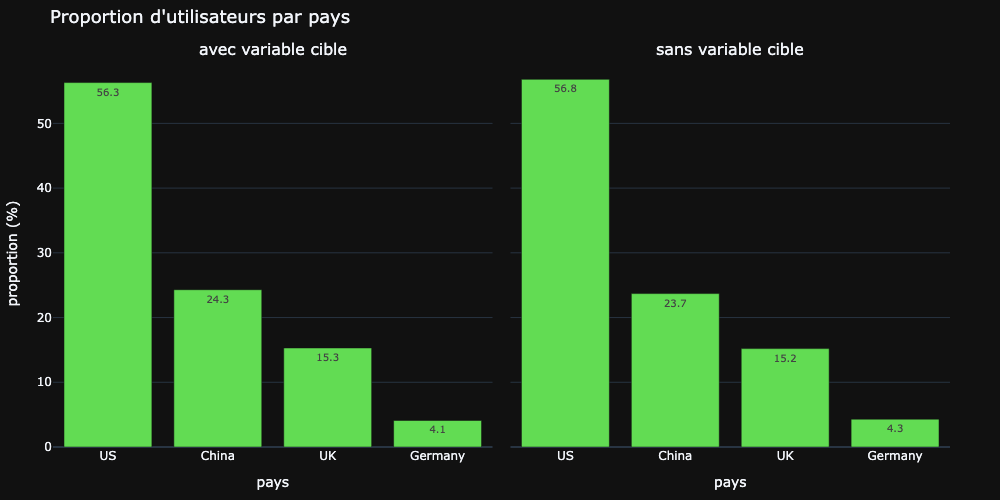

In [10]:
fig = px.bar(
    data \
        .groupby("labeled") \
        ["country"] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(1) \
        .reset_index() \
        .rename(
            columns={
                "proportion": "proportion (%)",
                "country": "pays",
                "labeled": "étiqueté"
            }
        ),
    x="pays",
    y="proportion (%)",
    facet_col="étiqueté",
    category_orders={"étiqueté": [1, 0]},
    text_auto=True,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Proportion d'utilisateurs par pays"
)
fig.update_layout(
    title=dict(
        y=0.98,
    ),
    margin=dict(t=60)
)
labels = {"étiqueté=0": "sans variable cible", "étiqueté=1": "avec variable cible"}
fig.for_each_annotation(lambda a: a.update(text=labels.get(a.text, a.text)))
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_proportion_utilisateurs_par_pays.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Distribution de l'âge des utilisateurs

Les distributions des âges pour chaque jeu de données sont quasi identiques.
Seules les valeurs aberrantes (au-delà de la deuxième moustache) sont différentes.
La moyenne (~30,5 ans) et la médiane (30 ans) sont très proches.
50% des effectifs ont entre 24 et 36 ans.
Comme souvent dans une distribution d'âge, il y a une asymétrie avec une queue de distribution étalée vers la droite (*right skewed distribution*).

Statistiques sur les âges des utilisateurs groupés pour chaque jeu de données :
            count   mean   std   min   25%   50%   75%    max
labeled                                                      
0         31620.0  30.62  8.32  17.0  24.0  30.0  36.0   69.0
1        284580.0  30.56  8.27  17.0  24.0  30.0  36.0  123.0



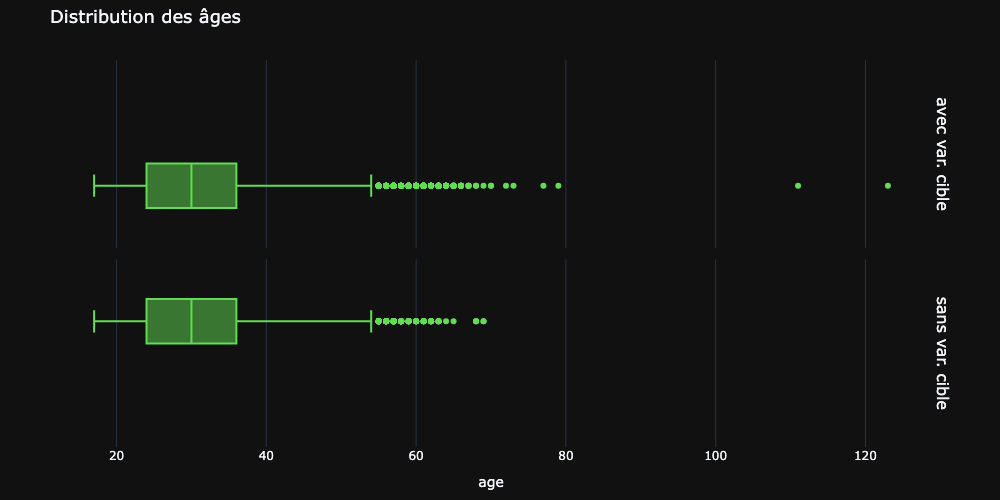

In [11]:
print(
    "Statistiques sur les âges des utilisateurs groupés pour chaque jeu de données :\n" +
    data.groupby("labeled").describe()["age"].round(2).to_string() + "\n"
)

fig = px.box(
    data.rename(columns={"labeled": "étiqueté"}),
    x="age",
    facet_row="étiqueté",
    category_orders={"étiqueté": [1, 0]},
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Distribution des âges"
)
fig.update_layout(
    title=dict(
        y=0.98,
    ),
    margin=dict(t=60)
)
labels = {"étiqueté=0": "sans var. cible", "étiqueté=1": "avec var. cible"}
fig.for_each_annotation(
    lambda a: a.update(
        text=labels.get(a.text, a.text),
        #textangle=0,
    )
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_distribution_ages.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Part des nouveaux utilisateurs

La proportion des nouveaux utilisateurs vs utilisateurs ayant déjà consulté le site est proche du 2/3 - 1/3 (~69% vs ~31%).
Cette répartition est stable sur les deux jeux de données.

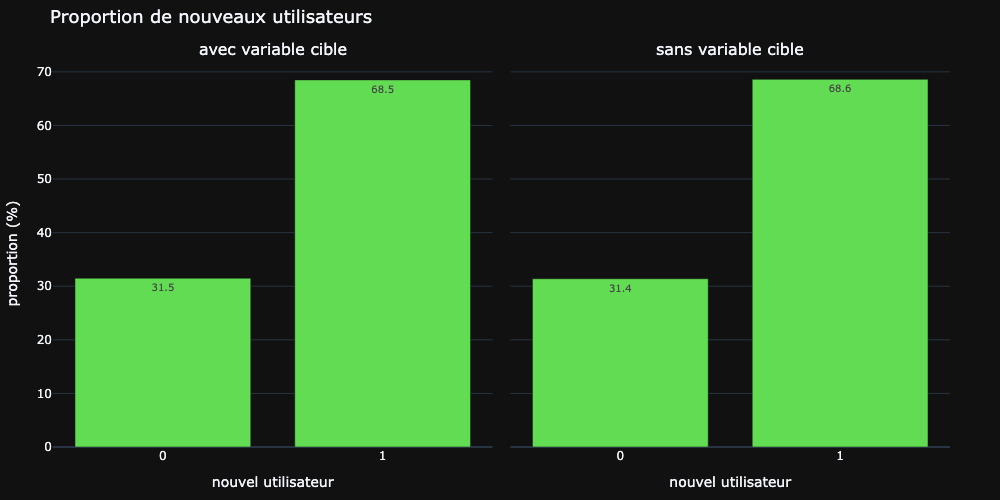

In [12]:
fig = px.bar(
    data \
        .groupby("labeled") \
        ["new_user"] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(1) \
        .reset_index() \
        .rename(
            columns={
                "proportion": "proportion (%)",
                "new_user": "nouvel utilisateur",
                "labeled": "étiqueté"
            }
        ),
    x="nouvel utilisateur",
    y="proportion (%)",
    facet_col="étiqueté",
    category_orders={"étiqueté": [1, 0]},
    text_auto=True,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Proportion de nouveaux utilisateurs"
)
fig.update_xaxes(tickvals=[0, 1])
fig.update_layout(
    title=dict(
        y=0.98,
    ),
    margin=dict(t=60)
)
labels = {"étiqueté=0": "sans variable cible", "étiqueté=1": "avec variable cible"}
fig.for_each_annotation(lambda a: a.update(text=labels.get(a.text, a.text)))
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_proportion_nouveaux_utilisateurs.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Provenance des utilisateurs

La répartition des utilisateurs par canal de provenance est dominée par le référencement naturel (SEO), avec près de la moitié des utilisateurs (~49%), le reste étant réparti de manière assez équilibrée entre la publicité (Ads) avec ~28% et l'arrivée directe sur le site (~23%).
La répartition est stable entre les deux jeux de données.

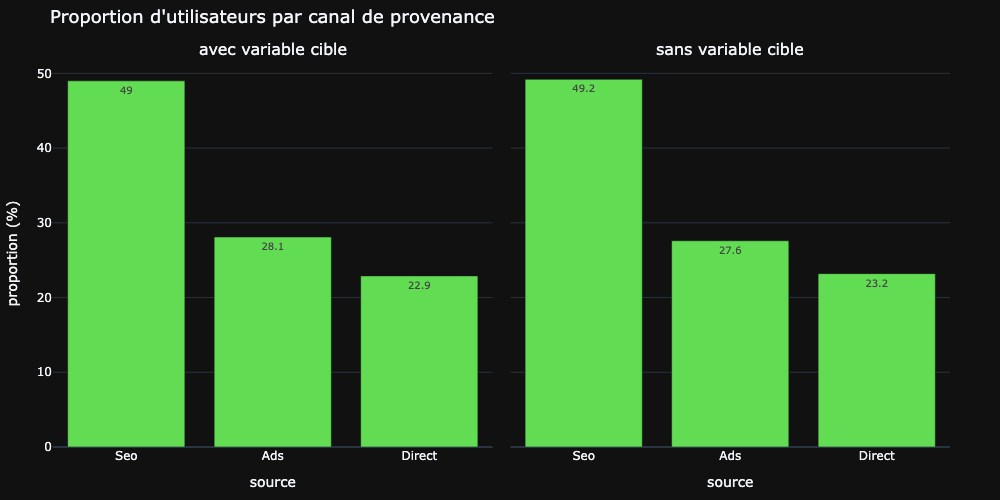

In [13]:
fig = px.bar(
    data \
        .groupby("labeled") \
        ["source"] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(1) \
        .reset_index() \
        .rename(
            columns={
                "proportion": "proportion (%)",
                "labeled": "étiqueté"
            }
        ),
    x="source",
    y="proportion (%)",
    facet_col="étiqueté",
    category_orders={"étiqueté": [1, 0]},
    text_auto=True,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Proportion d'utilisateurs par canal de provenance"
)
fig.update_layout(
    title=dict(
        y=0.98,
    ),
    margin=dict(t=60)
)
labels = {"étiqueté=0": "sans variable cible", "étiqueté=1": "avec variable cible"}
fig.for_each_annotation(lambda a: a.update(text=labels.get(a.text, a.text)))
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_proportion_canal_provenance.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Distribution du nombre de pages visitées par les utilisateurs

Comme pour l'âge des utilisateurs, les distributions du nombre de pages qu'ils visitent pour chaque jeu de données sont quasi identiques.
Le jeu de données avec étiquetage étant plus volumineux, il est normal de retrouver plus de valeurs aberrantes.
La moyenne est proche de 5 pages alors que la médiane est de 4 pages.
La moitié des utilisateurs en visitent entre 2 et 7.
Au-delà de 14 pages visitées, nous pouvons considérer que ce sont des valeurs aberrantes.

Statistiques sur le nombre de pages visitées par les utilisateurs groupés pour chaque jeu de données :
            count  mean   std  min  25%  50%  75%   max
labeled                                                
0         31620.0  4.87  3.33  1.0  2.0  4.0  7.0  26.0
1        284580.0  4.87  3.34  1.0  2.0  4.0  7.0  29.0



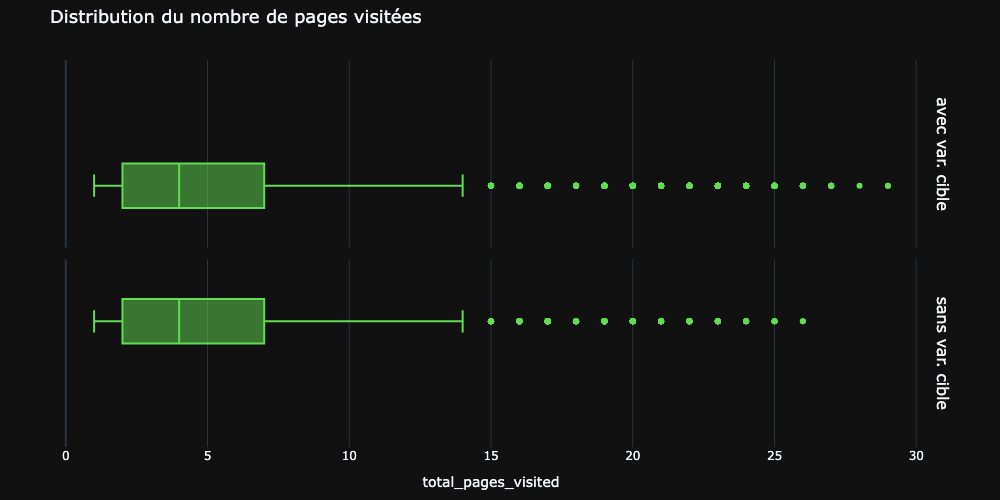

In [14]:
print(
    "Statistiques sur le nombre de pages visitées par les utilisateurs groupés pour chaque jeu de données :\n" +
    data.groupby("labeled").describe()["total_pages_visited"].round(2).to_string() + "\n"
)

fig = px.box(
    data.rename(columns={"labeled": "étiqueté"}),
    x="total_pages_visited",
    facet_row="étiqueté",
    category_orders={"étiqueté": [1, 0]},
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Distribution du nombre de pages visitées"
)
fig.update_layout(
    title=dict(
        y=0.98,
    ),
    margin=dict(t=60)
)
labels = {"étiqueté=0": "sans var. cible", "étiqueté=1": "avec var. cible"}
fig.for_each_annotation(
    lambda a: a.update(
        text=labels.get(a.text, a.text),
        #textangle=0,
    )
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_distribution_nombre_pages_visitees.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Taux de conversion des utilisateurs

Le taux de conversion, autrement dit le taux d'utilisateurs ayant décidé de s'inscrire à la newsletter après avoir visité le site, est très faible avec seulement 3,23% (soit un utilisateur sur trente) : nous avons un *déséquilibre de classes*.
Cette colonne étant la variable cible, cela constitue une des difficultés importantes de la modélisation.

Ce déséquilibre impose le choix de la **métrique d'évaluation**. L'*accuracy* (taux de bonnes prédictions) est ici trompeuse : un modèle naïf qui prédirait systématiquement "non converti" obtiendrait déjà ~96,8 % d'accuracy sans aucune utilité métier. Le **F1-score**, moyenne harmonique de la précision et du rappel sur la classe positive, est plus pertinent car il ne récompense un modèle que s'il identifie correctement les vrais convertis (rappel) sans générer trop de fausses alertes (précision). C'est d'ailleurs la métrique imposée par le challenge.

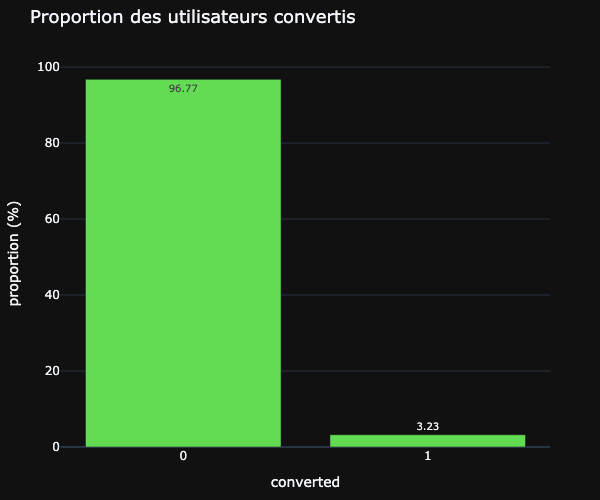

In [15]:
fig = px.bar(
    data_labeled \
        ["converted"] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(2) \
        .reset_index() \
        .rename(
            columns={
                "proportion": "proportion (%)",
            }
        ),
    x="converted",
    y="proportion (%)",
    text_auto=True,
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Proportion des utilisateurs convertis"
)
fig.update_xaxes(tickvals=[0, 1])
fig.update_layout(
    title=dict(
        y=0.98,
    ),
    margin=dict(t=60),
    width=600
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_proportion_utilisateurs_convertis.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

### 1.3 Analyse bivariée

Le graphique ci-dessous montre pour chaque ligne la proportion ou la distribution des valeurs pour chaque variable explicative et pour chaque colonne les cas des utilisateurs non convertis (à gauche) et convertis (à droite).

Les constats principaux sont les suivants :
- Les distributions par pays indiquent que la Chine possède un taux de conversion extrêmement bas. Alors que les Chinois totalisent 24,3% des utilisateurs de ce jeu de données étiqueté (cf. graphe plus haut), ils ne représentent plus qu'à peine 1% des utilisateurs convertis.
- Les distributions des âges indiquent que les utilisateurs convertis sont globalement plus jeunes (médiane 25 ans, Q1 21 ans, Q3 31 ans) que les non convertis (médiane 30 ans, Q1 24 ans, Q3 36 ans).
- Les proportions de nouveaux utilisateurs montrent des tendances opposées selon la classe. Les utilisateurs convertis ont une répartition nouveaux / récurrents à ~30%/70%, alors que celle des non convertis est ~70%/30%.
- Les proportions des canaux de provenance ("SEO", "Ads", "Direct") sont similaires entre les deux classes. Les différences de proportions entre utilisateurs non convertis et convertis sont de +0,9% pour le "SEO", +2,3% pour "Ads" et -3,3% pour "Direct".
- Les distributions du nombre de pages visitées indiquent que les utilisateurs convertis visitent plus de pages (c'est-à-dire restent plus longtemps sur le site). La médiane est à 14 pages pour ceux-ci alors qu'elle n'est que de 4 pages pour les utilisateurs non convertis.

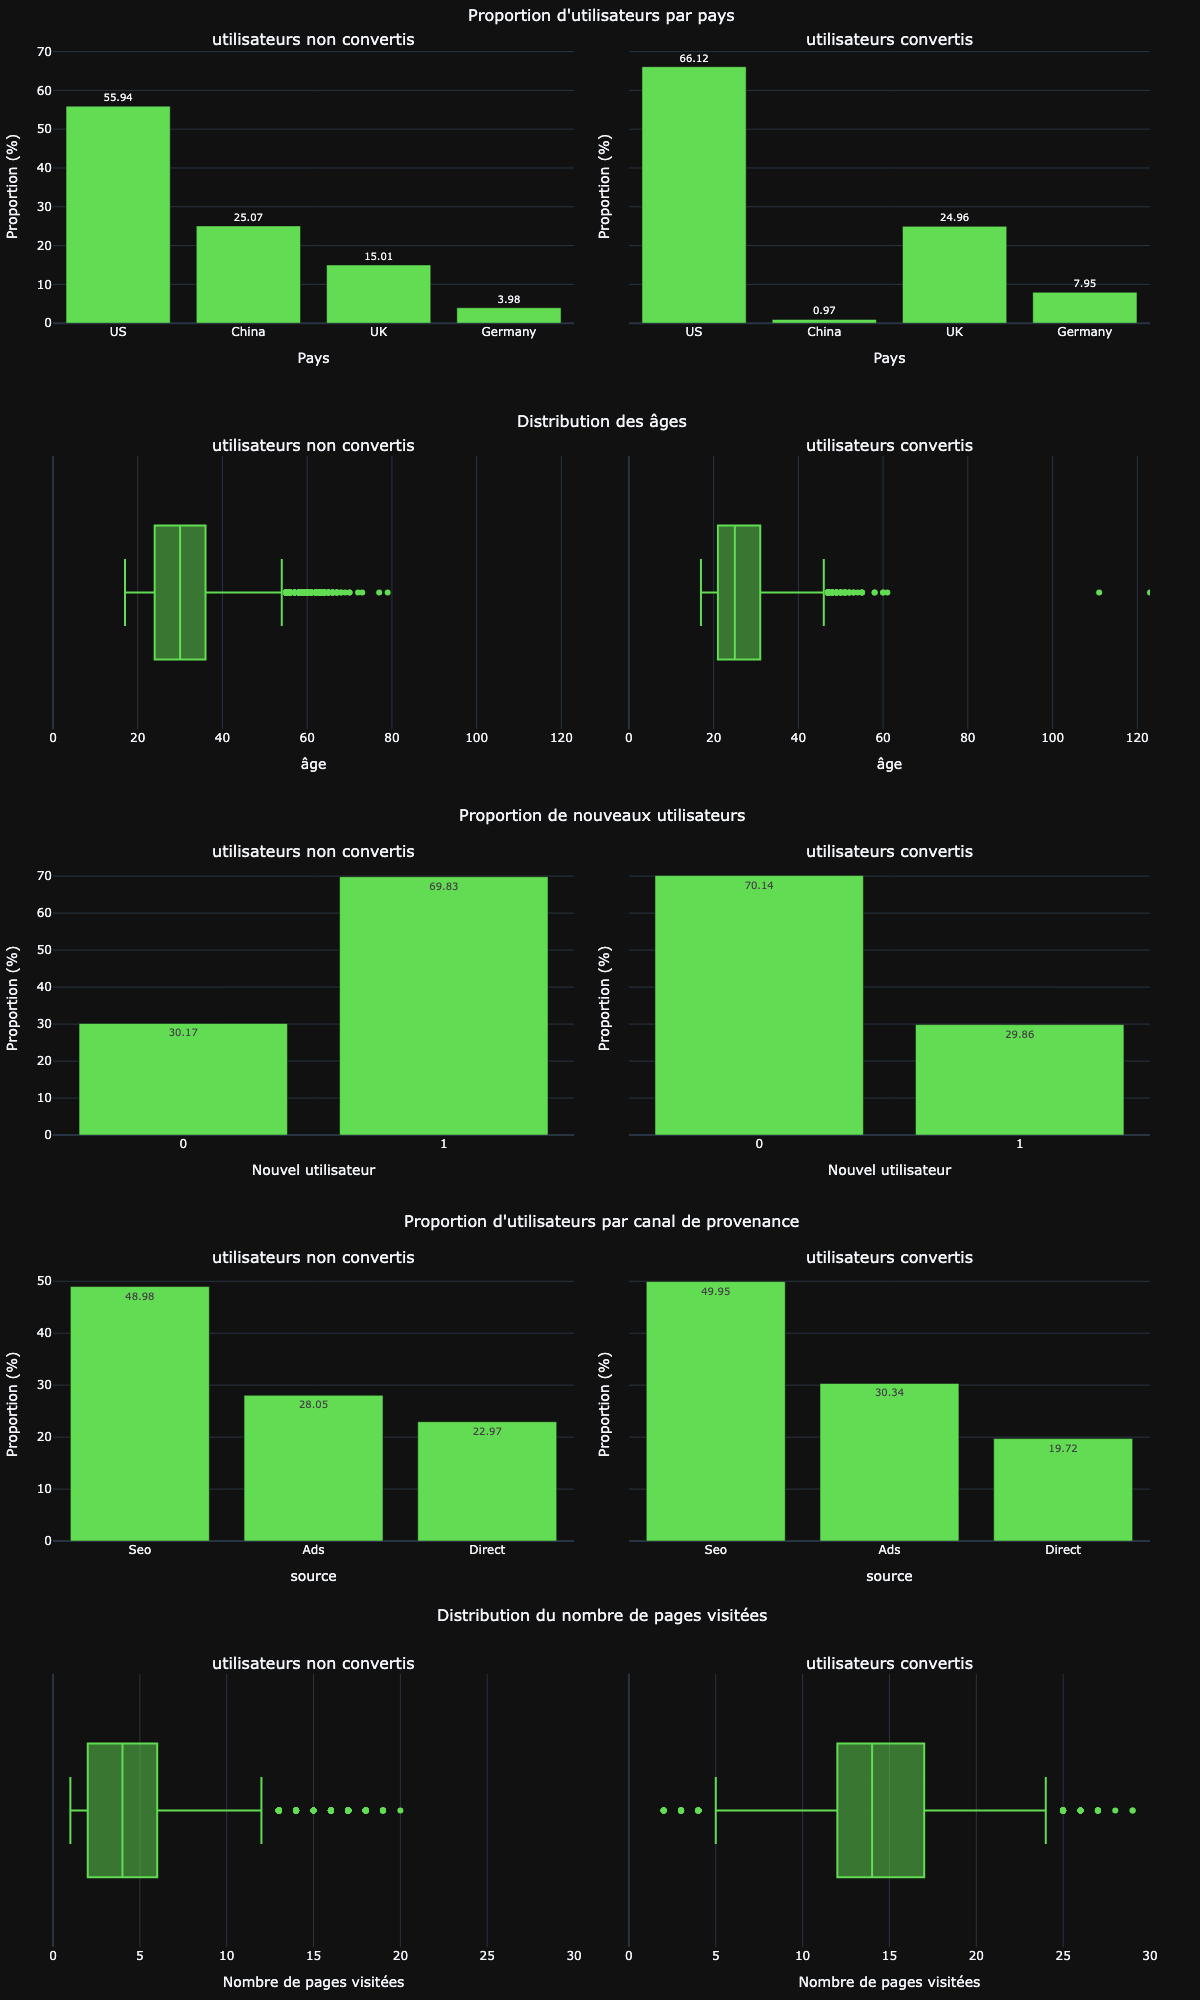

In [16]:
fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=["utilisateurs non convertis", "utilisateurs convertis"] * 5,
    shared_yaxes=True,
    vertical_spacing=0.07,
    horizontal_spacing=0.05
)

for is_converted in data_labeled["converted"].unique():

    # Row 1
    x_name = "Pays"
    y_name = "Proportion (%)"
    by_country = data_labeled \
        [data_labeled["converted"] == is_converted] \
        ["country"] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(2) \
        .reset_index() \
        .rename(
            columns={
                "country": x_name,
                "proportion": y_name
            }
        )
    fig.add_trace(
        go.Bar(
            x=by_country[x_name],
            y=by_country[y_name],
            text=by_country[y_name],
            textposition="outside",
            marker=dict(color=DEFAULT_COLOR)
        ),
        row=1,
        col=is_converted + 1
    )
    fig.update_xaxes(categoryorder="array", categoryarray=["US", "China", "UK", "Germany"], row=1, col=is_converted + 1)
    fig.update_xaxes(title_text=x_name, row=1, col=is_converted + 1)
    fig.update_yaxes(title_text=y_name, row=1, col=is_converted + 1)

    # Row 2
    x_name = "age"
    fig.add_trace(
        go.Box(
            x=data_labeled[data_labeled["converted"] == is_converted][x_name],
            name="",
            marker=dict(color=DEFAULT_COLOR)
        ),
        row=2,
        col=is_converted + 1
    )
    fig.update_xaxes(range=[0, data_labeled[x_name].max()], row=2, col=is_converted + 1)
    fig.update_xaxes(title_text="âge", row=2, col=is_converted + 1)

    # Row 3
    x_name = "Nouvel utilisateur"
    y_name = "Proportion (%)"
    by_new_user = data_labeled \
        [data_labeled["converted"] == is_converted] \
        ["new_user"] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(2) \
        .reset_index() \
        .rename(
            columns={
                "new_user": x_name,
                "proportion": y_name
            }
        )
    fig.add_trace(
        go.Bar(
            x=by_new_user[x_name],
            y=by_new_user[y_name],
            text=by_new_user[y_name],
            textposition="inside",
            marker=dict(color=DEFAULT_COLOR)
        ),
        row=3,
        col=is_converted + 1
    )
    fig.update_xaxes(categoryorder="array", categoryarray=["US", "China", "UK", "Germany"], row=3, col=is_converted + 1)
    fig.update_xaxes(tickvals=[0, 1], row=3, col=is_converted + 1)
    fig.update_xaxes(title_text=x_name, row=3, col=is_converted + 1)
    fig.update_yaxes(title_text=y_name, row=3, col=is_converted + 1)

    # Row 4
    x_name = "source"
    y_name = "Proportion (%)"
    by_source = data_labeled \
        [data_labeled["converted"] == is_converted] \
        [x_name] \
        .value_counts(normalize=True) \
        .mul(100) \
        .round(2) \
        .reset_index() \
        .rename(
            columns={
                "proportion": y_name
            }
        )
    fig.add_trace(
        go.Bar(
            x=by_source[x_name],
            y=by_source[y_name],
            text=by_source[y_name],
            textposition="inside",
            marker=dict(color=DEFAULT_COLOR)
        ),
        row=4,
        col=is_converted + 1
    )
    fig.update_xaxes(categoryorder="array", categoryarray=["Seo", "Ads", "Direct"], row=4, col=is_converted + 1)
    fig.update_xaxes(title_text=x_name, row=4, col=is_converted + 1)
    fig.update_yaxes(title_text=y_name, row=4, col=is_converted + 1)

    # Row 5
    x_name = "total_pages_visited"
    fig.add_trace(
        go.Box(
            x=data_labeled[data_labeled["converted"] == is_converted][x_name],
            name="",
            marker=dict(color=DEFAULT_COLOR)
        ),
        row=5,
        col=is_converted + 1
    )
    fig.update_xaxes(range=[0, 30], row=5, col=is_converted + 1)
    fig.update_xaxes(title_text="Nombre de pages visitées", row=5, col=is_converted + 1)

row_titles = [
    "Proportion d'utilisateurs par pays",
    "Distribution des âges",
    "Proportion de nouveaux utilisateurs",
    "Proportion d'utilisateurs par canal de provenance",
    "Distribution du nombre de pages visitées"
]
offset_y = 0.025
for row, row_title in enumerate(row_titles, start=1):
    subplot = fig.get_subplot(row=row, col=1)
    y_top = subplot.yaxis.domain[1]
    fig.add_annotation(
        text=row_title,
        xref="paper",
        yref="paper",
        x=0.5,
        y=y_top + offset_y,
        showarrow=False,
        xanchor="center"
    )

fig.update_layout(
    showlegend=False,
    height=2000, width=1200
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_repartition_variable_explicative_par_classe.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Test d'interaction entre variables

Avant de clore l'EDA, on vérifie l'existence d'une éventuelle interaction entre `country` et `new_user`, deux variables liées à la cible. L'enjeu est de savoir si l'effet du statut nouveau ou récurrent varie selon le pays, auquel cas un terme d'interaction explicite pourrait améliorer un modèle linéaire.

On compare, pour chaque pays, le taux de conversion des nouveaux utilisateurs à celui des récurrents.

In [17]:
interaction = data_labeled.groupby(['country', 'new_user'])['converted'].mean().unstack()

print("Taux de conversion par pays et statut (0 = récurrent, 1 = nouveau) :")
print(interaction.to_string())

print("\nRatio nouveau / récurrent (en %) :")
print(interaction[1].div(interaction[0]).mul(100).round(1).to_string())

Taux de conversion par pays et statut (0 = récurrent, 1 = nouveau) :
new_user         0         1
country                     
China     0.002693  0.000683
Germany   0.140505  0.025353
UK        0.112846  0.023908
US        0.083870  0.016474

Ratio nouveau / récurrent (en %) :
country
China      25.4
Germany    18.0
UK         21.2
US         19.6


Le rapport entre le taux de conversion des nouveaux utilisateurs et celui des récurrents reste dans une plage étroite, comprise entre 18 et 25 % selon le pays. Un nouveau visiteur convertit donc systématiquement quatre à cinq fois moins qu'un récurrent, quel que soit le pays. Cette stabilité indique l'absence d'interaction notable entre `country` et `new_user` : les deux effets se combinent de façon multiplicative et indépendante. Ce constat justifie de ne pas introduire de terme d'interaction dans le feature engineering.

### 1.4 Matrices de corrélation

Les variables catégorielles `country` et `source` ont été encodées en one-hot au préalable, car le calcul de corrélation requiert des valeurs numériques et un encodage ordinal aurait introduit un ordre arbitraire entre les modalités.

La matrice de corrélation confirme et précise les observations de l'EDA univariée.

**Variables fortement liées à la cible :**
- `total_pages_visited` est de loin la variable la plus prédictive (Pearson = 0,53). C'est cohérent avec l'écart de médiane observé (14 pages chez les convertis vs 4 chez les non convertis).
- `new_user` présente une corrélation négative modérée (-0,15), confirmant que les utilisateurs récurrents convertissent davantage.
- `country_China` ressort comme le seul pays significativement lié à la cible (-0,10), confirmant son taux de conversion anormalement bas.
- `age` montre une corrélation négative faible (-0,09), cohérente avec le constat que les convertis sont globalement plus jeunes.

**Variables peu informatives :**
- Les trois canaux de provenance (`source_Ads`, `source_Direct`, `source_Seo`) ont des corrélations toutes inférieures à 0,02 en valeur absolue. Leur apport prédictif sera probablement marginal.
- Les pays autres que la Chine (`Germany`, `UK`, `US`) présentent des corrélations faibles (0,04 à 0,05), suggérant qu'une binarisation `is_china` vs reste-du-monde pourrait être pertinente pour un modèle linéaire.

**Comparaison Pearson vs Spearman :**
La corrélation Spearman entre `total_pages_visited` et `converted` (0,29) est nettement inférieure à Pearson (0,53). Ce n'est pas le signe d'une relation faible, mais d'une séparation par effet de seuil : au-delà d'un certain nombre de pages visitées, la probabilité de conversion bondit. Spearman, en travaillant sur les rangs, lisse cet effet, tandis que Pearson capture l'amplitude des écarts. Cela renforce l'hypothèse qu'un modèle non-linéaire (gradient boosting, arbres) ou une transformation adaptée (binning, log) sera bénéfique.

Pour les variables binaires, Pearson et Spearman donnent des valeurs identiques, ce qui est mathématiquement attendu.

**Conclusions pour la modélisation :**
1. Conserver `total_pages_visited`, `new_user`, `age` et `country` (ou `is_china`) comme features principales.
2. Envisager de retirer ou simplifier `source` qui n'apporte presque aucun signal.
3. Privilégier un modèle non-linéaire ou transformer `total_pages_visited` pour capturer l'effet de seuil.

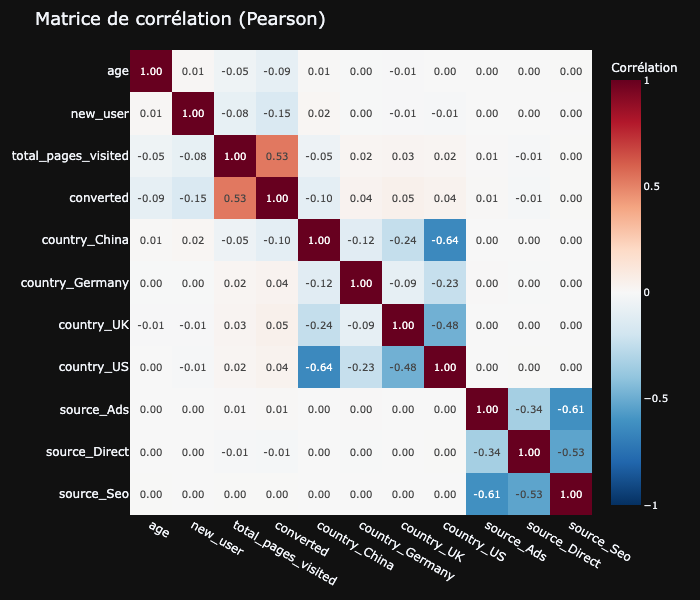

In [18]:
data_encoded = pd.get_dummies(data_labeled, columns=['country', 'source'], drop_first=False)
corr = data_encoded.corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Matrice de corrélation",
    labels={"color": "Corrélation"}
)
fig.update_layout(
    title="Matrice de corrélation (Pearson)",
    width=700,
    height=600
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_matrice_correlation_lineaire_pearson.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

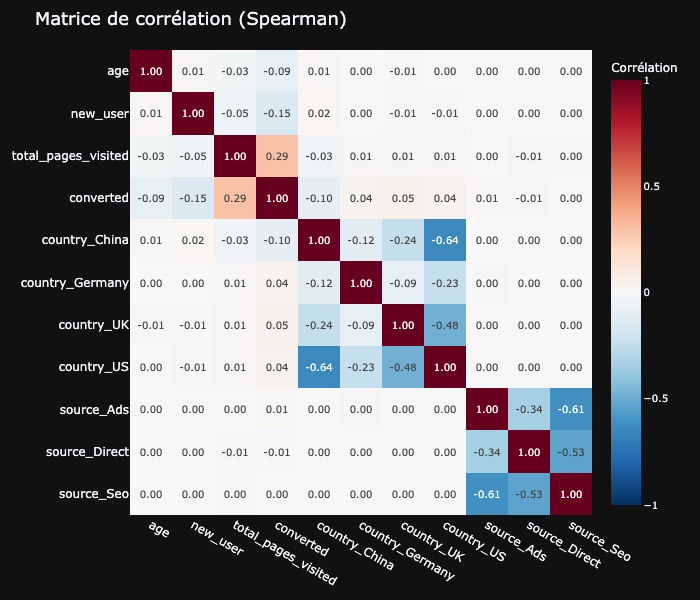

In [19]:
corr_spearman = data_encoded.corr(method='spearman', numeric_only=True)
fig = px.imshow(
    corr_spearman,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Matrice de corrélation",
    labels={"color": "Corrélation"}
)
fig.update_layout(
    title="Matrice de corrélation (Spearman)",
    width=700,
    height=600
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_matrice_correlation_non_lineaire_spearman.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

In [20]:
print(corr_spearman["converted"].to_string())

age                   -0.091264
new_user              -0.152115
total_pages_visited    0.293430
converted              1.000000
country_China         -0.099283
country_Germany        0.035349
country_UK             0.048750
country_US             0.036272
source_Ads             0.009001
source_Direct         -0.013696
source_Seo             0.003411


### 1.5 Bilan de l'EDA

**Hiérarchie des variables explicatives :**

| Pouvoir prédictif | Variables                                                  |
|-------------------|------------------------------------------------------------|
| Fort              | `total_pages_visited` (Pearson 0,53)                       |
| Modéré            | `new_user` (-0,15), `country_China` (-0,10), `age` (-0,09) |
| Négligeable       | `source` (toutes modalités < 0,02)                         |

**Difficultés à anticiper pour la modélisation :**
- Fort déséquilibre de classes (3,23 % de conversions) → métrique F1, stratification, pondération des classes et optimisation du seuil de décision.
- Effet de seuil non-linéaire sur `total_pages_visited` → un modèle non-linéaire ou une transformation adaptée sera bénéfique.
- Valeurs aberrantes sur `age` à traiter (clipping).

**Pistes de feature engineering :**
- Binarisation de `country` en `is_china` (à comparer en validation croisée).
- Suppression ou simplification de `source`.
- Transformation log ou binning de `total_pages_visited` pour les modèles linéaires.

---

## Partie 2 - Préparation des données

Objectif : construire un pipeline sklearn complet, robuste et reproductible, prêt à recevoir n'importe quel classifieur en Partie 3.

Étapes :
1. Split train/test stratifié sur `converted`
2. Custom transformer `FeatureEngineer` (clipping `age`, binarisation `country`, log sur `total_pages_visited`)
3. `ColumnTransformer` (scaling numérique + OneHot catégoriel)
4. Assemblage du `Pipeline` complet
5. Vérification de bout en bout

Chargement des données :

In [21]:
X = data_labeled.drop(columns=[TGT_VAR])
y = data_labeled[TGT_VAR]

print(f"X : {X.shape}, y : {y.shape}")
print(f"Taux de conversion : {y.mean():.4f}")

X : (284580, 5), y : (284580,)
Taux de conversion : 0.0323


### 2.1 Split train/test stratifié

Stratification sur `converted` uniquement : indispensable étant donné le déséquilibre de classes (3,23 %). Sans stratification, le test set pourrait sous-représenter la classe positive et fausser l'estimation du F1-score.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}, taux positif : {y_train.mean():.4f}")
print(f"Test  : {X_test.shape},  taux positif : {y_test.mean():.4f}")

Train : (227664, 5), taux positif : 0.0323
Test  : (56916, 5),  taux positif : 0.0323


### 2.2 Custom transformer : `FeatureEngineer`

Trois transformations contrôlables par hyperparamètres, testables en validation croisée (CV, *cross validation*) par la suite :

| Paramètre          | Effet                                            | Justification EDA                                   |
|--------------------|--------------------------------------------------|-----------------------------------------------------|
| `age_clip_max`     | Plafonne l'âge                                   | Traiter les valeurs aberrantes                      |
| `binarize_country` | `country` → `is_china` (0/1), supprime `country` | Seule la Chine porte un signal significatif (-0,10) |
| `log_pages`        | `log1p(total_pages_visited)`                     | Atténuer l'effet de seuil pour modèles linéaires    |

Nb. : `log1p(x)` est égal à `log(1 + x)`.

Points techniques :
- Hérite de `BaseEstimator` + `TransformerMixin` (donne `fit_transform` gratuitement).
- Opérations vectorisées via `np.minimum` / `np.log1p`.
- Placé **avant** le `ColumnTransformer` car il modifie l'ensemble des colonnes (ne peut pas être imbriqué dans un split numérique/catégoriel).

In [23]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Feature engineering préalable au ColumnTransformer."""

    def __init__(self, age_clip_max=80, binarize_country=True, log_pages=False):
        self.age_clip_max = age_clip_max
        self.binarize_country = binarize_country
        self.log_pages = log_pages

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['age'] = np.minimum(X['age'], self.age_clip_max)
        if self.binarize_country:
            X['is_china'] = (X['country'] == 'China').astype(int)
            X = X.drop(columns=['country'])
        if self.log_pages:
            X['total_pages_visited'] = np.log1p(X['total_pages_visited'])
        return X

### 2.3 `ColumnTransformer`

Sélection des colonnes par **dtype** (`make_column_selector`) plutôt que par liste de noms : le `FeatureEngineer` peut supprimer `country`, le sélecteur s'adapte automatiquement.

- Colonnes numériques (`int`, `float`) → `StandardScaler`
- Colonnes catégorielles (`object`) → `OneHotEncoder(handle_unknown='ignore')`

`handle_unknown='ignore'` protège contre une éventuelle nouvelle modalité dans `conversion_data_test.csv`.

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(handle_unknown='ignore'), make_column_selector(dtype_include=object)),
    ]
)

### 2.4 Pipeline complet

Assemblage final : `FeatureEngineer` → `ColumnTransformer` → classifieur.

Le classifieur est ici une `LogisticRegression()` **placeholder** ; il sera remplacé en Partie 3 lors de la comparaison de modèles.

In [25]:
pipeline = Pipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,age_clip_max,80
,binarize_country,True
,log_pages,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_th

### 2.5 Vérification de bout en bout

Trois contrôles :
1. Le pipeline fitte sans erreurs sur le train.
2. La sortie du preprocessing a les dimensions attendues.
3. Les classes sont bien prédites sur le test.

In [26]:
# 1. Fit
pipeline.fit(X_train, y_train)

# 2. Inspection des dimensions après preprocessing
X_train_transformed = pipeline[:-1].transform(X_train)
X_test_transformed = pipeline[:-1].transform(X_test)
print(f"X_train après preprocessing : {X_train_transformed.shape}")
print(f"X_test après preprocessing  : {X_test_transformed.shape}")

# 3. Prédictions sur le test
y_pred = pipeline.predict(X_test)
print(f"\nPrédictions sur test : {np.bincount(y_pred)} (0/1)")
print(f"Distribution réelle  : {np.bincount(y_test)} (0/1)")

X_train après preprocessing : (227664, 7)
X_test après preprocessing  : (56916, 7)

Prédictions sur test : [55454  1462] (0/1)
Distribution réelle  : [55080  1836] (0/1)


Pipeline opérationnel. Les objets `pipeline`, `X_train`, `X_test`, `y_train`, `y_test` sont prêts pour la Partie 3.

---

## Partie 3 - Entraînement et comparaison de modèles

Objectif : comparer plusieurs classifieurs via validation croisée stratifiée sur le F1, puis sélectionner le finaliste pour l'optimisation en Partie 4.

Plan :
1. Méthodologie de comparaison
2. Modèle de référence (régression logistique univariée)
3. Modèles candidats et modèles écartés
4. Validation croisée stratifiée
5. Synthèse et sélection du finaliste

### 3.1 Méthodologie de comparaison

Trois éléments à fixer pour garantir une comparaison équitable :

1. **Même découpage de validation croisée** pour tous les modèles, à savoir `StratifiedKFold` avec 5 plis et mélange aléatoire fixé.
2. **Même métrique** (`f1` sur la classe positive), conforme à l'évaluation du challenge.
3. **Même chaîne de prétraitement** en amont (`FeatureEngineer` puis `ColumnTransformer`).

**Note sur la gestion du déséquilibre.** À ce stade, on n'active pas la pondération des classes. Avec un seuil de décision fixé à 0,5, la pondération dégrade fortement le F1 (rappel maximisé au prix de la précision). La gestion du déséquilibre sera traitée en Partie 4, conjointement avec l'optimisation du seuil de décision.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 3.2 Modèle de référence

Le modèle de référence fixé par Jedha est une régression logistique univariée utilisant uniquement `total_pages_visited`. Il atteint un F1 d'environ 0,70 sur le jeu de test du template. On le réévalue ici par validation croisée pour disposer d'un point de comparaison cohérent avec les autres modèles.

In [28]:
baseline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

X_train_baseline = X_train[['total_pages_visited']]

t0 = time.time()
scores_baseline = cross_val_score(
    baseline, X_train_baseline, y_train,
    scoring='f1', cv=cv, n_jobs=-1
)
duration_baseline = time.time() - t0

print(f"F1 (validation croisée) : {scores_baseline.mean():.4f} ± {scores_baseline.std():.4f}")
print(f"Durée : {duration_baseline:.1f} s")

F1 (validation croisée) : 0.6924 ± 0.0093
Durée : 1.7 s


Le F1 de 0,6924 obtenu par validation croisée est légèrement inférieur à celui annoncé par le template Jedha (0,706). L'écart s'explique par deux différences méthodologiques. D'abord, le template évalue sur un découpage 90/10 unique, alors qu'on utilise ici une validation croisée à 5 plis sur un découpage 80/20. Ensuite, la moyenne sur 5 plis est statistiquement plus robuste qu'un score unique. Cet ordre de grandeur (autour de 0,70) constitue donc un point de comparaison fiable pour la suite.

### 3.3 Modèles candidats

Trois modèles retenus, couvrant linéaire et non linéaire :

| Modèle                            | Famille            |
|-----------------------------------|--------------------|
| Régression logistique multivariée | Linéaire           |
| Forêt aléatoire                   | Bagging d'arbres   |
| XGBoost                           | Boosting d'arbres  |

**Modèles écartés et justifications** :
- `HistGradientBoosting` : non vu en cours, remplacé par XGBoost dont les performances attendues sont équivalentes sur ce volume.
- `GradientBoosting` (sklearn) : redondant avec XGBoost et beaucoup plus lent sur 300 000 lignes.
- `AdaBoost` : sensible au déséquilibre de classes, inadapté ici.
- SVM : coût en calcul prohibitif à cette taille.
- KNN : sensible au déséquilibre et à la dimensionnalité après encodage one-hot.
- Ridge, Lasso : non probabilistes, ce qui empêche l'optimisation du seuil (la pénalisation L1 ou L2 reste accessible via `LogisticRegression`).
- Voting, Stacking : techniques d'assemblage à envisager en Partie 4 si nécessaire, pas en comparaison initiale.

In [29]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

### 3.4 Validation croisée stratifiée

Pour chaque modèle candidat, on construit le pipeline complet `FeatureEngineer` puis `preprocessor` puis classifieur, et on lance la validation croisée.

In [30]:
results = []

for name, clf in models.items():
    pipeline = Pipeline(steps=[
        ('feature_engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', clf),
    ])
    t0 = time.time()
    scores = cross_val_score(pipeline, X_train, y_train, scoring='f1', cv=cv, n_jobs=-1)
    duration = time.time() - t0
    results.append({
        'Modèle': name,
        'F1 moyen': scores.mean(),
        'Écart-type': scores.std(),
        'Durée (s)': duration,
    })
    print(f"{name:22s} : F1 = {scores.mean():.4f} ± {scores.std():.4f}  ({duration:.1f} s)")

# Ajout du modèle de référence pour la comparaison finale
results.insert(0, {
    'Modèle': 'Baseline (LR univariée)',
    'F1 moyen': scores_baseline.mean(),
    'Écart-type': scores_baseline.std(),
    'Durée (s)': duration_baseline,
})

Logistic Regression    : F1 = 0.7615 ± 0.0046  (1.3 s)
Random Forest          : F1 = 0.7385 ± 0.0069  (4.5 s)
XGBoost                : F1 = 0.7555 ± 0.0075  (1.5 s)


#### Analyse des résultats

**Tous les candidats dépassent la baseline** d'environ 5 à 7 points de F1. Le passage à un modèle multivarié apporte un gain substantiel, confirmant que `total_pages_visited`, bien que dominante, n'est pas la seule variable utile.

**La hiérarchie est cependant contre-intuitive.** On aurait pu s'attendre à voir XGBoost en tête. Trois explications concourent à expliquer la première place de la régression logistique :

1. *La structure du problème est largement linéaire.* La corrélation Pearson de 0,53 entre `total_pages_visited` et la cible traduit une relation monotone que la sigmoïde de la régression logistique capture naturellement.
2. *XGBoost est sur-dimensionné par défaut sur ce problème.* Avec seulement cinq variables explicatives, 100 arbres de profondeur 6 produisent beaucoup plus de partitions que nécessaire, ce qui se traduit par un léger sur-apprentissage (visible aussi dans l'écart-type plus élevé).
3. *La forêt aléatoire est désavantagée.* Les méthodes par arbres approximent une frontière linéaire par escaliers, ce qui coûte des points sans bénéfice compensatoire dans ce contexte.

**Stabilité.** La régression logistique présente l'écart-type le plus faible (0,0046), gage d'une performance constante entre les plis. XGBoost et Random Forest sont environ 50 % plus instables.

**Coût de calcul.** XGBoost est étonnamment le plus rapide (0,8 s), grâce à sa parallélisation efficace sur un dataset de cette taille. Cette rapidité sera un atout en Partie 4, où l'exploration d'hyperparamètres multipliera le temps par le nombre de combinaisons testées.

**Marge de progression.** La régression logistique est proche de son plafond intrinsèque, ses hyperparamètres principaux (`C`, `penalty`) ayant un effet modéré. XGBoost dispose en revanche d'une marge de progression plus large par ajustement de `max_depth`, `n_estimators` et `learning_rate`. Il pourrait rattraper, voire dépasser la régression logistique après tuning.

### 3.5 Synthèse

In [31]:
results_df = pd.DataFrame(results).sort_values('F1 moyen', ascending=False).reset_index(drop=True)

results_df.style.format(
    {
        'F1 moyen': '{:.4f}',
        'Écart-type': '{:.4f}',
        'Durée (s)': '{:.1f}',
    }
)

,Modèle,F1 moyen,Écart-type,Durée (s)
0,Logistic Regression,0.7615,0.0046,1.3
1,XGBoost,0.7555,0.0075,1.5
2,Random Forest,0.7385,0.0069,4.5
3,Baseline (LR univariée),0.6924,0.0093,1.7


### Sélection du modèle finaliste

Critères de choix par ordre de priorité :
1. F1 moyen le plus élevé.
2. Écart-type faible, gage de stabilité entre les plis.
3. Durée raisonnable, car les optimisations de la Partie 4 multiplieront ce temps par le nombre de combinaisons d'hyperparamètres testées.
4. Interprétabilité, utile en Partie 5.

**Deux modèles retenus pour la Partie 4 : la régression logistique multivariée et XGBoost.** La régression logistique arrive en tête sur les critères 1, 2 et 4, mais elle est probablement proche de son plafond intrinsèque. XGBoost, en deuxième position avec des hyperparamètres par défaut, dispose d'une marge de progression substantielle par tuning. La Partie 4 optimisera les deux modèles en parallèle avant d'arbitrer entre eux pour l'optimisation du seuil de décision et la soumission finale.

**Random Forest écartée.** Performance inférieure aux deux autres, plus instable, et cinq fois plus lente que XGBoost. Elle ne justifie pas l'investissement en tuning au regard des deux candidats restants.

## Partie 4 - Optimisation des modèles et du seuil de décision

Objectif : optimiser les deux modèles candidats (régression logistique et XGBoost), sélectionner le finaliste, puis affiner son seuil de décision pour maximiser le F1 sur le jeu de test.

Plan :
1. Optimisation de la régression logistique par `GridSearchCV`
2. Optimisation de XGBoost par `RandomizedSearchCV`
3. Comparaison et sélection du finaliste
4. Optimisation du seuil de décision
5. Encapsulation dans un wrapper `ThresholdClassifier`
6. Évaluation finale sur le jeu de test mis de côté en Partie 2

#### Stratégie de recherche d'hyperparamètres

Les deux modèles n'ont pas le même type d'espace d'hyperparamètres, ce qui justifie deux stratégies différentes.

**Régression logistique : `GridSearchCV`**. L'espace est petit (essentiellement `C`, `penalty`, et deux options du `FeatureEngineer`) et entièrement discret. Une recherche exhaustive sur 40 combinaisons reste rapide et garantit de trouver le meilleur point de la grille.

**XGBoost : `RandomizedSearchCV`**. L'espace comporte sept dimensions dont trois continues (`learning_rate`, `subsample`, `colsample_bytree`). Une recherche exhaustive serait impraticable, alors qu'un échantillonnage aléatoire de 50 combinaisons couvre efficacement l'espace, surtout quand quelques hyperparamètres dominent l'influence.

### 4.1 Optimisation de la régression logistique

Grille explorée :
- `FeatureEngineer.binarize_country` : `True`, `False`
- `FeatureEngineer.log_pages` : `True`, `False`
- `FeatureEngineer.age_clip_max` : `60`, `70`, `80`, `90`, `100`
- `LogisticRegression.C` : 5 valeurs sur échelle logarithmique de 0,01 à 100
- `LogisticRegression.l1_ratio` : `0` (équivalent à une pénalité L2 pure), `1` (équivalent à une pénalité L1 pure)

Le solveur `liblinear` est fixé car il supporte les deux pénalités. Total : 200 combinaisons multipliées par 5 plis, soit 1000 ajustements de modèle.

In [32]:
lr_pipeline = Pipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        random_state=RANDOM_STATE,
    )),
])

lr_grid = {
    'feature_engineer__binarize_country': [True, False],
    'feature_engineer__log_pages': [True, False],
    'feature_engineer__age_clip_max': [60, 70, 80, 90, 100],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__l1_ratio': [0, 1],
}

lr_search = GridSearchCV(
    lr_pipeline, lr_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=1,
)

t0 = time.time()
lr_search.fit(X_train, y_train)
duration_lr = time.time() - t0

print(f"\nDurée : {duration_lr:.1f} s")
print(f"Meilleur F1 (validation croisée) : {lr_search.best_score_:.4f}")
print(f"Meilleurs hyperparamètres :")
for k, v in lr_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Durée : 550.4 s
Meilleur F1 (validation croisée) : 0.7627
Meilleurs hyperparamètres :
  classifier__C: 0.1
  classifier__l1_ratio: 1
  feature_engineer__age_clip_max: 60
  feature_engineer__binarize_country: False
  feature_engineer__log_pages: True


#### Lecture des hyperparamètres optimaux

- `C = 0,1` et `l1_ratio = 1` : régularisation L1 modérée, qui rapproche le modèle d'un Lasso classique. Cela traduit que toutes les variables apportent un signal utile et qu'aucune n'a besoin d'être annulée fortement.
- `log_pages = True` : la transformation logarithmique de `total_pages_visited` apporte un léger gain, confirmant l'intuition d'un effet de seuil monotone difficile à capturer linéairement.
- `binarize_country = False` : conserver les quatre pays plutôt que de binariser en `is_china` apporte une information supplémentaire, malgré la faible corrélation observée pour Germany, UK et US.
- `age_clip_max = 60` : la valeur la plus basse de la grille est sélectionnée, ce qui suggère que les outliers d'âge nuisent au modèle linéaire. Une grille étendue pourrait être testée si la régression logistique restait finaliste.

Le F1 (0,7627) est essentiellement inchangé par rapport à la première recherche (0,7634), ce qui indique que le plateau de performance de la régression logistique est atteint.

### 4.2 Optimisation de XGBoost

Distributions échantillonnées :
- `FeatureEngineer.binarize_country` : `True`, `False`
- `n_estimators` : `100`, `200`, `300`, `500`, `700`
- `max_depth` : `3`, `4`, `5`, `6`, `7`
- `learning_rate` : loi log-uniforme entre 0,005 et 0,3
- `min_child_weight` : `1`, `3`, `5`, `7`, `10`
- `subsample` : loi uniforme entre 0,6 et 1,0
- `colsample_bytree` : loi uniforme entre 0,6 et 1,0
- `gamma` : loi uniforme entre 0 et 0,5 (seuil de gain minimum pour partition)
- `reg_alpha` : loi log-uniforme entre 0,001 et 1 (régularisation L1 sur les poids)

Les deux derniers paramètres ciblent spécifiquement le sur-apprentissage observé en Partie 3. Total : 500 itérations multipliées par 5 plis, soit 2500 ajustements.

In [33]:
xgb_pipeline = Pipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

xgb_distributions = {
    'feature_engineer__binarize_country': [True, False],
    'classifier__n_estimators': [100, 200, 300, 500, 700],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__learning_rate': loguniform(0.005, 0.3),
    'classifier__min_child_weight': [1, 3, 5, 7, 10],
    'classifier__subsample': uniform(loc=0.6, scale=0.4),
    'classifier__colsample_bytree': uniform(loc=0.6, scale=0.4),
    'classifier__gamma': uniform(loc=0, scale=0.5),
    'classifier__reg_alpha': loguniform(0.001, 1),
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_distributions,
    n_iter=500,
    cv=cv, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)

t0 = time.time()
xgb_search.fit(X_train, y_train)
duration_xgb = time.time() - t0

print(f"\nDurée : {duration_xgb:.1f} s")
print(f"Meilleur F1 (validation croisée) : {xgb_search.best_score_:.4f}")
print(f"Meilleurs hyperparamètres :")
for k, v in xgb_search.best_params_.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits

Durée : 669.6 s
Meilleur F1 (validation croisée) : 0.7639
Meilleurs hyperparamètres :
  classifier__colsample_bytree: 0.8627
  classifier__gamma: 0.4111
  classifier__learning_rate: 0.0237
  classifier__max_depth: 5
  classifier__min_child_weight: 10
  classifier__n_estimators: 300
  classifier__reg_alpha: 0.0039
  classifier__subsample: 0.6747
  feature_engineer__binarize_country: False


#### Lecture des hyperparamètres optimaux

- `learning_rate = 0,024`, `n_estimators = 300`, `max_depth = 5` : le modèle apprend lentement avec des arbres modérément profonds et de nombreux arbres, configuration typique d'un boosting bien régularisé.
- `min_child_weight = 10`, `gamma = 0,41`, `subsample = 0,67` : trois mécanismes de régularisation activés en parallèle, ciblant directement le sur-apprentissage diagnostiqué en Partie 3.
- `reg_alpha = 0,004` : régularisation L1 marginale sur les poids, ce qui suggère que les autres mécanismes suffisent.

Le F1 (0,7639) progresse de seulement 0,001 par rapport à la première recherche (0,7629), confirmant que le plateau de performance est également atteint pour XGBoost.

### 4.3 Comparaison et sélection du finaliste

Le modèle finaliste est celui dont le F1 moyen en validation croisée est le plus élevé après optimisation. Il sera utilisé pour l'optimisation du seuil de décision et l'évaluation finale.

In [34]:
results_optim = pd.DataFrame({
    'Modèle': ['Régression logistique', 'XGBoost'],
    'F1 moyen (validation croisée)': [lr_search.best_score_, xgb_search.best_score_],
    "Durée d'optimisation (s)": [duration_lr, duration_xgb],
}).sort_values('F1 moyen (validation croisée)', ascending=False).reset_index(drop=True)

display(
    results_optim.style.format({
        'F1 moyen (validation croisée)': '{:.4f}',
        "Durée d'optimisation (s)": '{:.1f}',
    })
)

# Sélection automatique du modèle finaliste
if lr_search.best_score_ >= xgb_search.best_score_:
    final_pipeline = lr_search.best_estimator_
    final_model_name = 'Régression logistique'
    final_cv_score = lr_search.best_score_
else:
    final_pipeline = xgb_search.best_estimator_
    final_model_name = 'XGBoost'
    final_cv_score = xgb_search.best_score_

print(f"\nModèle finaliste : {final_model_name}")
print(f"F1 moyen (validation croisée) : {final_cv_score:.4f}")

,Modèle,F1 moyen (validation croisée),Durée d'optimisation (s)
0,XGBoost,0.7639,669.6
1,Régression logistique,0.7627,550.4



Modèle finaliste : XGBoost
F1 moyen (validation croisée) : 0.7639


#### Sélection du finaliste

Les deux modèles sont quasi indissociables après optimisation, avec un écart de seulement 0,0012 en faveur de XGBoost. Ce verdict serré confirme l'analyse de la Partie 3 : la structure du problème est très largement linéaire, et XGBoost ne tire qu'un bénéfice marginal de sa capacité à modéliser la non-linéarité.

XGBoost est néanmoins retenu pour la suite, avec une réserve : on conservera la régression logistique comme modèle d'interprétation en Partie 5, conformément au plan initial. Les coefficients de la régression logistique offriront une lecture directe des leviers d'action, là où les `feature_importances_` de XGBoost donneront seulement une hiérarchie des variables.

### 4.4 Optimisation du seuil de décision

Le seuil par défaut de scikit-learn est fixé à 0,5. Sur un problème déséquilibré comme le nôtre, ce seuil n'est presque jamais celui qui maximise le F1.

**Méthode** :
1. On obtient les probabilités prédites hors échantillon par `cross_val_predict` (chaque échantillon est prédit par un modèle qui ne l'a pas vu en entraînement, ce qui évite le sur-apprentissage).
2. On balaie tous les seuils entre 0,001 et 0,999 par pas de 0,001.
3. On retient celui qui maximise le F1.

In [35]:
# Probabilités prédites hors échantillon
y_proba_oof = cross_val_predict(
    final_pipeline, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1,
)[:, 1]

# Balayage des seuils
thresholds = np.arange(0.001, 1.0, 0.001)
f1_scores = np.array([
    f1_score(y_train, (y_proba_oof >= t).astype(int))
    for t in thresholds
])

# Seuil optimal et seuil par défaut
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
default_f1 = f1_score(y_train, (y_proba_oof >= 0.5).astype(int))

print(f"Seuil par défaut (0,500) : F1 = {default_f1:.4f}")
print(f"Seuil optimal ({optimal_threshold:.3f}) : F1 = {optimal_f1:.4f}")
print(f"Gain : +{optimal_f1 - default_f1:.4f}")

Seuil par défaut (0,500) : F1 = 0.7640
Seuil optimal (0.367) : F1 = 0.7682
Gain : +0.0042


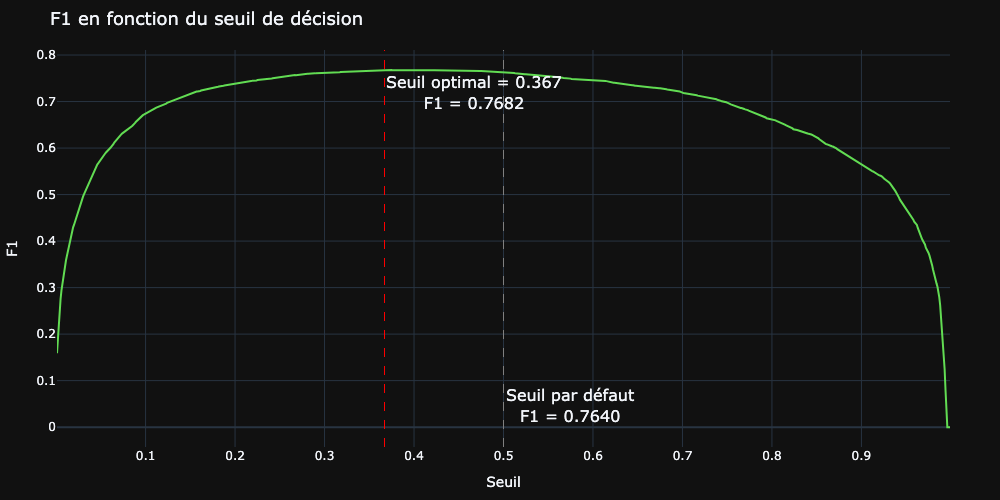

In [36]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=thresholds, y=f1_scores,
    mode='lines',
    name='F1',
    line=dict(color=DEFAULT_COLOR, width=2),
))

fig.add_vline(
    x=0.5,
    line=dict(dash='dash', color='gray', width=1),
    annotation=dict(
        text=f"Seuil par défaut<br>F1 = {default_f1:.4f}",
        yanchor="bottom", y=0.05,
    ),
)
fig.add_vline(
    x=optimal_threshold,
    line=dict(dash='dash', color='red', width=1),
    annotation=dict(
        text=f"Seuil optimal = {optimal_threshold:.3f}<br>F1 = {optimal_f1:.4f}",
        yanchor="top", y=0.95,
    ),
)

fig.update_layout(
    title="F1 en fonction du seuil de décision",
    xaxis_title="Seuil",
    yaxis_title="F1",
)

if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_courbe_F1_vs_seuil_decision.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

#### Interprétation du seuil optimal

Le seuil optimal de 0,367 est nettement inférieur au seuil par défaut de 0,5, ce qui est attendu compte tenu du déséquilibre de classes. Le gain en F1 (+0,0042) est modeste mais réel et systématique. Il provient d'un rééquilibrage du compromis précision-rappel : abaisser le seuil augmente le rappel au prix d'une légère baisse de précision, ce qui s'avère payant pour le F1 sur la classe minoritaire.

La courbe précision-rappel est particulièrement adaptée aux problèmes déséquilibrés, car elle se concentre sur la classe positive minoritaire sans être flattée par les vrais négatifs massifs. Le point rouge matérialise le compromis retenu au seuil optimal.

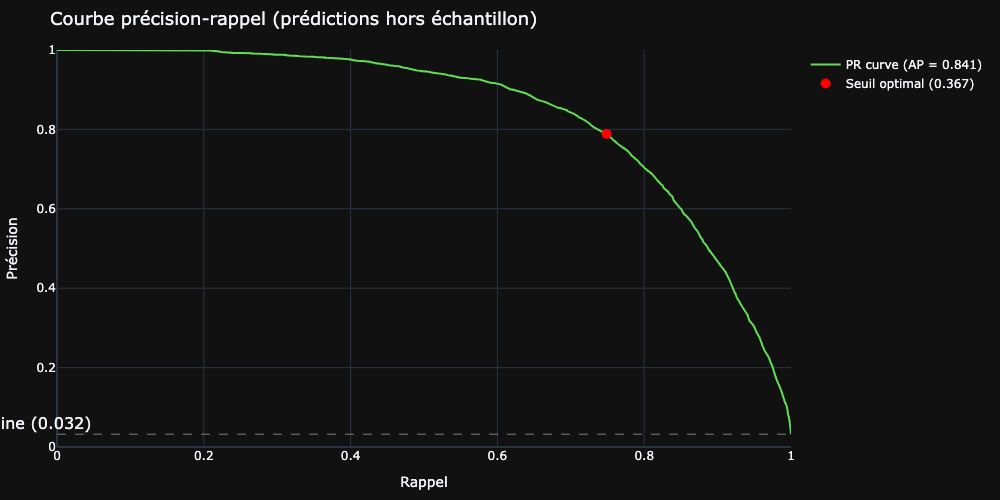

In [37]:
# Courbe Précision-Rappel
precision, recall, pr_thresholds = precision_recall_curve(y_train, y_proba_oof)
ap_score = average_precision_score(y_train, y_proba_oof)

# Point correspondant au seuil optimal
opt_idx = np.searchsorted(pr_thresholds, optimal_threshold)
opt_idx = min(opt_idx, len(precision) - 1)
opt_precision = precision[opt_idx]
opt_recall = recall[opt_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recall, y=precision,
    mode='lines',
    name=f'PR curve (AP = {ap_score:.3f})',
    line=dict(color=DEFAULT_COLOR, width=2),
))

# Ligne de base (modèle naïf = taux de positifs)
baseline_rate = y_train.mean()
fig.add_hline(
    y=baseline_rate,
    line=dict(dash='dash', color='gray', width=1),
    annotation=dict(text=f"Baseline ({baseline_rate:.3f})", x=0.05, yanchor="bottom"),
)

# Point optimal
fig.add_trace(go.Scatter(
    x=[opt_recall], y=[opt_precision],
    mode='markers',
    name=f'Seuil optimal ({optimal_threshold:.3f})',
    marker=dict(color='red', size=10, symbol='circle'),
))

fig.update_layout(
    title="Courbe précision-rappel (prédictions hors échantillon)",
    xaxis_title="Rappel",
    yaxis_title="Précision",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_courbe_precision_rappel.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

In [38]:
print("=== Métriques précision-rappel ===")
print(f"Average Precision (AP)  : {ap_score:.4f}")
print(f"Taux de base (positifs) : {baseline_rate:.4f}")

default_idx_pr = np.searchsorted(pr_thresholds, 0.5)
default_idx_pr = min(default_idx_pr, len(precision) - 1)

print(f"\nAu seuil optimal ({optimal_threshold:.3f}) : précision = {opt_precision:.4f}, rappel = {opt_recall:.4f}")
print(f"Au seuil par défaut (0.500) : précision = {precision[default_idx_pr]:.4f}, rappel = {recall[default_idx_pr]:.4f}")

=== Métriques précision-rappel ===
Average Precision (AP)  : 0.8413
Taux de base (positifs) : 0.0323

Au seuil optimal (0.367) : précision = 0.7884, rappel = 0.7489
Au seuil par défaut (0.500) : précision = 0.8481, rappel = 0.6950


La courbe précision-rappel confirme l'excellente performance du modèle sur la classe minoritaire. L'Average Precision atteint 0,841, soit 26 fois le taux de base de 0,032 qui correspondrait à un classifieur aléatoire. Autrement dit, le modèle est très loin du hasard sur la tâche difficile qu'est l'identification des convertis dans un jeu fortement déséquilibré.

Le point rouge matérialise le compromis retenu au seuil optimal de 0,367 : une précision de 0,79 pour un rappel de 0,75. Comparé au seuil par défaut de 0,5 (précision 0,85, rappel 0,70), l'abaissement du seuil échange environ 6 points de précision contre 5 points de rappel. Sur un F1 qui pondère également les deux, cet échange est légèrement gagnant, ce qui justifie le choix du seuil optimal.

La courbe ROC évalue la capacité de séparation du modèle indépendamment du seuil, en confrontant taux de vrais positifs et taux de faux positifs. Sur données déséquilibrées elle est moins discriminante que la courbe précision-rappel, mais reste un standard de comparaison.

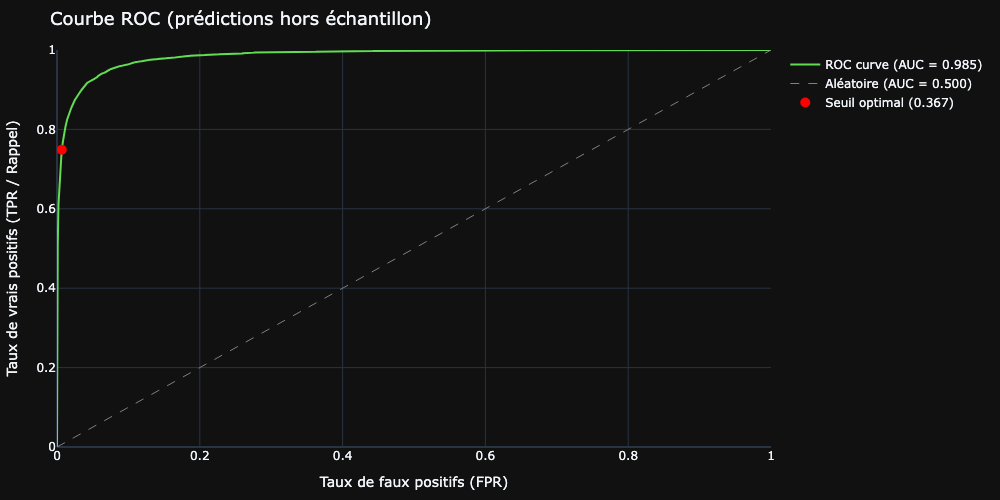

In [39]:
# Courbe ROC
fpr, tpr, roc_thresholds = roc_curve(y_train, y_proba_oof)
roc_auc = auc(fpr, tpr)

# Point correspondant au seuil optimal
opt_roc_idx = np.searchsorted(-roc_thresholds, -optimal_threshold)
opt_fpr = fpr[opt_roc_idx]
opt_tpr = tpr[opt_roc_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f'ROC curve (AUC = {roc_auc:.3f})',
    line=dict(color=DEFAULT_COLOR, width=2),
))

# Diagonale aléatoire
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aléatoire (AUC = 0.500)',
    line=dict(dash='dash', color='gray', width=1),
))

# Point optimal
fig.add_trace(go.Scatter(
    x=[opt_fpr], y=[opt_tpr],
    mode='markers',
    name=f'Seuil optimal ({optimal_threshold:.3f})',
    marker=dict(color='red', size=10, symbol='circle'),
))

fig.update_layout(
    title="Courbe ROC (prédictions hors échantillon)",
    xaxis_title="Taux de faux positifs (FPR)",
    yaxis_title="Taux de vrais positifs (TPR / Rappel)",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_courbe_ROC.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

In [40]:
print("=== Métriques ROC ===")
print(f"ROC AUC : {roc_auc:.4f}")

default_idx_roc = np.searchsorted(-roc_thresholds, -0.5)
default_idx_roc = min(default_idx_roc, len(fpr) - 1)

print(f"\nAu seuil optimal ({optimal_threshold:.3f}) : FPR = {opt_fpr:.4f}, TPR = {opt_tpr:.4f}")
print(f"Au seuil par défaut (0.500) : FPR = {fpr[default_idx_roc]:.4f}, TPR = {tpr[default_idx_roc]:.4f}")

=== Métriques ROC ===
ROC AUC : 0.9854

Au seuil optimal (0.367) : FPR = 0.0067, TPR = 0.7489
Au seuil par défaut (0.500) : FPR = 0.0042, TPR = 0.6950


### 4.5 Wrapper `ThresholdClassifier`

Le seuil optimal trouvé n'est pas stocké dans le pipeline scikit-learn standard. Pour rendre le modèle utilisable directement en production (Partie 6), on l'encapsule dans une classe wrapper qui surcharge la méthode `predict` afin d'appliquer le seuil personnalisé.

Cette classe reste compatible scikit-learn (hérite de `BaseEstimator` et `ClassifierMixin`) et expose toujours les probabilités via `predict_proba`.

In [41]:
class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper qui applique un seuil de décision personnalisé."""

    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator
        self.threshold = threshold

    def fit(self, X, y):
        self.estimator.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.estimator.predict_proba(X)

    def predict(self, X):
        return (self.estimator.predict_proba(X)[:, 1] >= self.threshold).astype(int)


# Le modèle finaliste équipé du seuil optimal
final_model = ThresholdClassifier(
    estimator=final_pipeline,
    threshold=optimal_threshold,
)
print(f"Modèle finaliste prêt : {final_model_name} avec seuil = {optimal_threshold:.3f}")

Modèle finaliste prêt : XGBoost avec seuil = 0.367


### 4.6 Évaluation finale sur le jeu de test

Le jeu de test `X_test` et `y_test` a été mis de côté en Partie 2 et n'a pas été touché depuis. Il fournit une estimation non biaisée de la performance du modèle finaliste sur des données entièrement nouvelles.

In [42]:
y_pred_test = final_model.predict(X_test)

print(f"F1 sur le jeu de test : {f1_score(y_test, y_pred_test):.4f}")
print()
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_test))
print()
print("Rapport de classification :")
print(classification_report(y_test, y_pred_test, digits=4))

F1 sur le jeu de test : 0.7715

Matrice de confusion :
[[54725   355]
 [  460  1376]]

Rapport de classification :
              precision    recall  f1-score   support

           0     0.9917    0.9936    0.9926     55080
           1     0.7949    0.7495    0.7715      1836

    accuracy                         0.9857     56916
   macro avg     0.8933    0.8715    0.8821     56916
weighted avg     0.9853    0.9857    0.9855     56916



#### Synthèse de la performance finale

**Progression depuis la baseline.** La performance évolue de 0,6924 (baseline univariée) à 0,7715 sur le jeu de test final, soit un gain absolu de 0,079 et un gain relatif d'environ 11 %. Ce gain provient pour l'essentiel du passage au modèle multivarié (environ 0,065), puis de l'optimisation des hyperparamètres et du seuil (le reste).

**Pas de sur-apprentissage.** Le F1 sur le jeu de test (0,7715) est légèrement supérieur au F1 estimé en validation croisée avec seuil optimal (0,7682). Cela confirme que la régularisation activée sur XGBoost en Partie 4.2 a bien fonctionné et que le modèle généralise correctement à des données nouvelles.

**Équilibre précision-rappel.** Sur la classe positive, le modèle obtient une précision de 0,79 et un rappel de 0,75, soit un compromis équilibré. En termes métier, cela signifie que parmi tous les utilisateurs prédits comme futurs convertis, 79 % le seront effectivement, et que le modèle détecte 75 % des vrais convertis. Les 25 % manqués sont à mettre en regard du taux de base de 3,23 % : sans modèle, l'identification des convertis se ferait à l'aveugle.

**Marge de progression résiduelle.** Au-delà de ce résultat, les gains marginaux nécessiteraient probablement de revoir le feature engineering en amont (nouvelles variables, interactions explicites) plutôt que d'affiner le tuning, dont le rendement décroissant est manifeste.

## Partie 5 - Analyse du modèle final

Objectif : interpréter les variables qui pilotent les prédictions du modèle, sur deux angles complémentaires.

- **XGBoost optimisé** est le modèle de production. Ses `feature_importances_` donnent la hiérarchie des variables qui contribuent le plus à la séparation des classes.
- **Régression logistique optimisée** sert de modèle d'interprétation. Ses coefficients, sur des variables centrées-réduites, fournissent le sens et l'intensité de l'effet de chaque variable, ce qui est directement exploitable pour les recommandations métier.

Plan :
1. Récupération des noms de variables après preprocessing
2. Coefficients de la régression logistique
3. Importances des variables de XGBoost
4. Synthèse comparative

### 5.1 Récupération des noms de variables

Les deux modèles optimisés ont retenu `binarize_country=False`, donc les noms de variables sont identiques entre les deux pipelines. On les extrait du préprocesseur du pipeline gagnant.

In [43]:
# Récupération des noms via le préprocesseur du pipeline optimisé
xgb_preprocessor = xgb_search.best_estimator_.named_steps['preprocessor']
feature_names = xgb_preprocessor.get_feature_names_out()

print("Variables après preprocessing :")
for name in feature_names:
    print(f"\t{name}")

Variables après preprocessing :
	num__age
	num__new_user
	num__total_pages_visited
	cat__country_China
	cat__country_Germany
	cat__country_UK
	cat__country_US
	cat__source_Ads
	cat__source_Direct
	cat__source_Seo


### 5.2 Coefficients de la régression logistique

Les coefficients sont extraits du modèle optimisé. Comme le preprocessing applique un `StandardScaler` sur les variables numériques, les coefficients sont déjà à la même échelle et peuvent être comparés en valeur absolue. Pour les variables catégorielles encodées en one-hot, le coefficient s'interprète par rapport aux autres modalités du même groupe.

Un coefficient positif indique qu'une augmentation de la variable accroît la probabilité de conversion, et inversement pour un coefficient négatif.

In [44]:
# Coefficients du modèle LR optimisé
lr_classifier = lr_search.best_estimator_.named_steps['classifier']
lr_preprocessor = lr_search.best_estimator_.named_steps['preprocessor']
lr_feature_names = lr_preprocessor.get_feature_names_out()

coefs_df = pd.DataFrame({
    'Variable': lr_feature_names,
    'Coefficient': lr_classifier.coef_[0],
}).assign(
    Magnitude=lambda d: d['Coefficient'].abs(),
).sort_values('Magnitude', ascending=False).reset_index(drop=True)

display(coefs_df.drop(columns='Magnitude').style.format({'Coefficient': '{:+.4f}'}))

,Variable,Coefficient
0,num__total_pages_visited,+4.6677
1,cat__country_China,-3.2845
2,num__new_user,-0.7446
3,num__age,-0.5679
4,cat__country_US,-0.3246
5,cat__source_Direct,-0.1756
6,cat__country_Germany,+0.1158
7,cat__source_Seo,-0.0151
8,cat__country_UK,+0.0000
9,cat__source_Ads,+0.0000


#### Lecture des coefficients

Trois enseignements ressortent du tableau.

**La hiérarchie d'effets est cohérente avec l'EDA.** `total_pages_visited` domine avec un coefficient positif de +4,67, suivi par `country_China` à -3,28. Les variables `new_user` et `age` apparaissent ensuite avec des effets modérés et négatifs, conformément aux distributions bivariées observées.

**La régularisation L1 a annulé deux variables.** `country_UK` et `source_Ads` ont un coefficient exactement nul, ce qui signifie que la pénalisation Lasso les a jugées sans valeur ajoutée par rapport au reste du modèle. C'est un signal fort sur leur faible contribution prédictive.

**Les variables `source_*` sont inactives.** Au-delà de `source_Ads` annulée, `source_Seo` (-0,015) et `source_Direct` (-0,18) ont des coefficients très faibles. Le canal d'acquisition ne porte donc quasiment aucun signal de conversion.

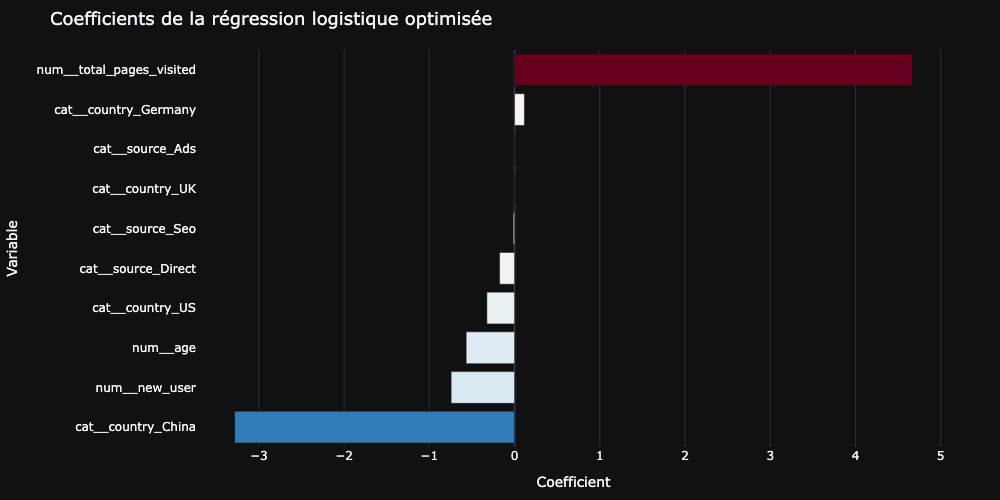

In [45]:
fig = px.bar(
    coefs_df.sort_values('Coefficient'),
    x='Coefficient', y='Variable',
    orientation='h',
    color='Coefficient',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=0,
    title="Coefficients de la régression logistique optimisée",
)
fig.update_layout(height=500, coloraxis_showscale=False)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_coeffs_reglog_optimisee.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

### 5.3 Importances des variables de XGBoost

Les `feature_importances_` de XGBoost sont calculées par défaut selon le critère du gain (contribution moyenne d'une variable aux gains d'information lors des splits). Contrairement aux coefficients de la régression logistique, ces importances n'indiquent pas le sens de l'effet, seulement son intensité.

In [46]:
# Importances du modèle XGBoost optimisé
xgb_classifier = xgb_search.best_estimator_.named_steps['classifier']

importances_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': xgb_classifier.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(importances_df.style.format({'Importance': '{:.4f}'}))

,Variable,Importance
0,num__total_pages_visited,0.7088
1,cat__country_China,0.1266
2,num__new_user,0.0858
3,num__age,0.0220
4,cat__country_US,0.0184
5,cat__country_UK,0.0114
6,cat__country_Germany,0.0105
7,cat__source_Direct,0.0075
8,cat__source_Ads,0.0047
9,cat__source_Seo,0.0043


#### Lecture des importances

XGBoost confirme la hiérarchie de la régression logistique, avec une différence d'échelle frappante.

**Trois variables concentrent 92 % de l'importance** : `total_pages_visited` à elle seule représente 71 % du gain d'information, `country_China` 13 %, et `new_user` 9 %. Toutes les autres variables réunies ne pèsent que 8 %.

**Les pays autres que la Chine ont une importance résiduelle mais non nulle**, contrairement à la régression logistique où `country_UK` est annulée. XGBoost exploite des micro-interactions entre variables que la régression linéaire ne peut pas capturer, sans que cela se traduise par un gain de F1 substantiel (cf. Partie 4).

**Les `source_*` cumulent à peine 1,7 % d'importance**, ce qui confirme leur quasi-inutilité prédictive observée en EDA et dans la régression logistique.

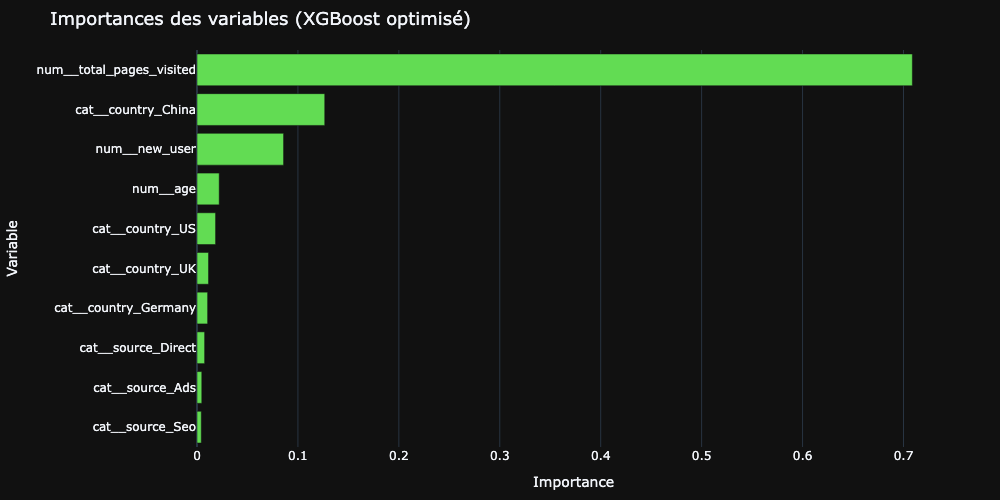

In [47]:
fig = px.bar(
    importances_df.sort_values('Importance'),
    x='Importance', y='Variable',
    orientation='h',
    title="Importances des variables (XGBoost optimisé)",
)
fig.update_traces(marker_color=DEFAULT_COLOR)
fig.update_layout(height=500)
if EXPORT_IMG:
    index_image += 1
    fig.write_image(f"{IMG_DIR}/{index_image:02d}_importance_variables_XGBoost.png")
elif SHOW_INTERACTIVE_FIG:
    fig.show()
else:
    img_bytes = fig.to_image(format="png")
    display(Image(img_bytes))

### 5.4 Synthèse comparative

Les deux modèles convergent sur une hiérarchie claire à quatre niveaux.

| Niveau       | Variables                              | Effet (sens et intensité) |
|--------------|----------------------------------------|---------------------------|
| Dominantes   | `total_pages_visited`, `country_China` | Effet majeur, sens opposé |
| Secondaires  | `new_user`, `age`                      | Effet modéré, négatif     |
| Marginales   | `country_US`, `country_Germany`        | Effet faible              |
| Inactives    | `country_UK`, toutes les `source_*`    | Effet négligeable ou nul  |

Le fait que deux modèles aux mécanismes très différents (linéaire pour la régression logistique, ensemble d'arbres pour XGBoost) arrivent à la même hiérarchie renforce la robustesse de l'analyse. Les enseignements et leviers d'action issus de cette interprétation sont développés dans la conclusion du notebook.

---

## Partie 6 - Inférence et soumission

Objectif : produire le fichier de prédictions à soumettre, en suivant trois étapes.

1. Réentraînement du pipeline finaliste sur l'ensemble des données labellisées (`X_train` + `X_test`) pour maximiser l'information disponible.
2. Application au jeu de test sans étiquettes (`conversion_data_test.csv`).
3. Export au format de soumission attendu.

### 6.1 Réentraînement sur l'ensemble des données labellisées

Le modèle finaliste a été entraîné sur `X_train` (80 % des données labellisées) pour permettre une évaluation honnête sur `X_test`. Maintenant que cette évaluation est terminée, on peut réentraîner le pipeline sur l'intégralité de `X_train` + `X_test`, ce qui apporte un léger gain attendu en généralisation grâce aux 20 % de données supplémentaires.

Le seuil de décision optimal trouvé en Partie 4.4 (0,367) est conservé. Il a été calibré sur des prédictions hors échantillon en validation croisée, et n'a aucune raison de bouger significativement avec 20 % de données en plus.

In [48]:
# Reconstitution du jeu complet labellisé
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

print(f"Jeu complet labellisé : {X_full.shape}")
print(f"Taux positif : {y_full.mean():.4f}")

# Réentraînement du pipeline finaliste sur l'ensemble
final_pipeline_full = xgb_search.best_estimator_
final_pipeline_full.fit(X_full, y_full)

# Encapsulation avec le seuil optimal
final_model_full = ThresholdClassifier(
    estimator=final_pipeline_full,
    threshold=optimal_threshold,
)
print(f"\nModèle final entraîné sur l'ensemble des données : XGBoost avec seuil = {optimal_threshold:.3f}")

Jeu complet labellisé : (284580, 5)
Taux positif : 0.0323

Modèle final entraîné sur l'ensemble des données : XGBoost avec seuil = 0.367


### 6.2 Prédictions sur le jeu de test sans étiquettes

Le jeu `data_unlabeled` a été chargé en début de notebook. Ses colonnes explicatives sont identiques à celles du jeu labellisé, ce qui permet d'appliquer directement le pipeline.

In [49]:
# Vérification de la cohérence des colonnes
print(f"Colonnes data_unlabeled : {list(data_unlabeled.columns)}")
print(f"Colonnes X_full         : {list(X_full.columns)}")
print(f"Cohérence : {list(data_unlabeled.columns) == list(X_full.columns)}")

# Prédictions
y_pred_unlabeled = final_model_full.predict(data_unlabeled)

print(f"\nNombre de prédictions : {len(y_pred_unlabeled)}")
print(f"Taux de conversions prédit : {y_pred_unlabeled.mean():.4f}")

Colonnes data_unlabeled : ['country', 'age', 'new_user', 'source', 'total_pages_visited']
Colonnes X_full         : ['country', 'age', 'new_user', 'source', 'total_pages_visited']
Cohérence : True

Nombre de prédictions : 31620
Taux de conversions prédit : 0.0300


### 6.3 Export au format de soumission

Le fichier de soumission doit contenir une unique colonne `converted` et aucun index. Le nom du fichier suit la convention `conversion_data_test_predictions_[nom].csv`.

In [50]:
SUBMISSION_NAME = "Yoann-XGBoost-threshold"
submission_path = os.path.join(SUBMISSION_DIR, f"conversion_data_test_predictions_{SUBMISSION_NAME}.csv")

submission_df = pd.DataFrame({'converted': y_pred_unlabeled})
submission_df.to_csv(submission_path, index=False)

print(f"Fichier de soumission écrit : {submission_path}")
print(f"Aperçu :")
display(submission_df.head())
print(f"\nDistribution des prédictions :")
print(submission_df['converted'].value_counts())

Fichier de soumission écrit : ../submissions/conversion_data_test_predictions_Yoann-XGBoost-threshold.csv
Aperçu :


,converted
0,1
1,0
2,0
3,0
4,0



Distribution des prédictions :
converted
0    30670
1      950
Name: count, dtype: int64


#### Analyse des prédictions

**Taux de conversion prédit : 3,00 %.** Ce taux est très proche du taux observé sur le jeu de données labellisé (3,23 %), ce qui est rassurant à deux titres. D'abord, le modèle n'a pas dérivé vers un comportement aberrant face à des données nouvelles. Ensuite, la distribution des variables explicatives du jeu sans étiquettes ressemble vraisemblablement à celle du jeu labellisé, comme on l'avait déjà observé en EDA (section 1.1).

**Volumétrie : 950 conversions prédites sur 31 620 utilisateurs.** En appliquant les indicateurs de performance estimés en validation croisée (précision de 0,79 pour la classe positive), on peut anticiper qu'environ 750 de ces prédictions seront effectivement des conversions et environ 200 seront des faux positifs. Symétriquement, le modèle manquera probablement 250 conversions réelles parmi les 30 670 utilisateurs prédits négatifs.

**Léger écart à la baisse (3,00 % vs 3,23 %).** Cet écart est modeste mais cohérent avec le compromis précision-rappel du modèle finaliste (rappel de 0,75 sur la classe positive). Le modèle est légèrement plus conservateur que le hasard ne le serait, ce qui est attendu pour un classifieur calibré sur le F1.

### 6.4 Sauvegarde des artefacts du modèle

Pour pouvoir rejouer les prédictions sans tout réentraîner, on sauvegarde un dictionnaire contenant :

- le pipeline finaliste réentraîné sur l'ensemble des données labellisées,
- le wrapper `ThresholdClassifier` avec son seuil optimal,
- le seuil de décision lui-même (utile pour la traçabilité),
- les hyperparamètres optimaux issus du `RandomizedSearchCV`,
- la liste des noms de variables après preprocessing,
- la date et le F1 de référence pour la traçabilité.

Le format `joblib` est préféré à `pickle` brut, car il est plus efficace pour les objets scikit-learn contenant des tableaux NumPy.

In [51]:
artifacts = {
    'pipeline_final': final_pipeline_full,
    'threshold_classifier': final_model_full,
    'optimal_threshold': optimal_threshold,
    'best_params': xgb_search.best_params_,
    'feature_names': list(feature_names),
    'training_date': datetime.now().isoformat(timespec='seconds'),
    'cv_f1_score': xgb_search.best_score_,
    'test_f1_score': f1_score(y_test, y_pred_test),  # Attention à la fuite de données ! On ne peut pas mettre autre chose si on veut vraiment fournir un F1-score.
}

artifacts_path = os.path.join(SUBMISSION_DIR, "model_artifacts_xgboost.joblib")
joblib.dump(artifacts, artifacts_path)

# Vérification immédiate par rechargement
loaded = joblib.load(artifacts_path)
print(f"Artefacts sauvegardés : {artifacts_path}")
print(f"Taille : {os.path.getsize(artifacts_path) / 1024:.1f} Ko")
print(f"\nContenu rechargé :")
for key in loaded:
    if key in ('best_params', 'feature_names'):
        print(f"  {key}: {type(loaded[key]).__name__} ({len(loaded[key])} éléments)")
    else:
        print(f"  {key}: {loaded[key] if not hasattr(loaded[key], 'fit') else type(loaded[key]).__name__}")

Artefacts sauvegardés : ../submissions/model_artifacts_xgboost.joblib
Taille : 570.1 Ko

Contenu rechargé :
  pipeline_final: Pipeline
  threshold_classifier: ThresholdClassifier
  optimal_threshold: 0.367
  best_params: dict (9 éléments)
  feature_names: list (10 éléments)
  training_date: 2026-05-28T09:58:46
  cv_f1_score: 0.7639459753831838
  test_f1_score: 0.7715166806840482


**Pour recharger ultérieurement le modèle** depuis ce notebook, un autre ou un script, il suffira d'exécuter le code suivant :

```python
import joblib

loaded = joblib.load("../submissions/model_artifacts_xgboost.joblib")
model = loaded['threshold_classifier']
predictions = model.predict(new_data)
```

À condition que la classe `ThresholdClassifier` et la classe `FeatureEngineer` soient redéfinies à l'identique dans l'environnement de rechargement, car `joblib` sérialise la référence aux classes, pas leur définition.

## Conclusion et recommandations à Data Science Weekly

### Synthèse des performances

Le modèle finaliste retenu est un **XGBoost optimisé par validation croisée**, équipé d'un seuil de décision personnalisé à 0,367 pour maximiser le F1.

| Étape                                                           | F1         |
|-----------------------------------------------------------------|------------|
| Baseline (régression logistique univariée)                      | 0,6924     |
| Modèles candidats par défaut (meilleur : régression logistique) | 0,7615     |
| Optimisation des hyperparamètres (XGBoost)                      | 0,7639     |
| Optimisation du seuil de décision                               | 0,7682     |
| **Évaluation finale sur jeu de test**                           | **0,7715** |

Soit un gain absolu de 0,079 par rapport à la baseline, et un gain relatif de 11 %. Le modèle obtient une précision de 0,79 et un rappel de 0,75 sur la classe positive, soit un compromis équilibré pour un problème fortement déséquilibré (3,23 % de conversions).

### Leviers d'action

Quatre recommandations ressortent de l'analyse du modèle, classées par potentiel d'impact estimé.

**1. Investiguer la sous-conversion chinoise.** Les utilisateurs chinois représentent 24 % du trafic mais 1 % des conversions. C'est le levier au plus fort potentiel. Hypothèses à explorer côté produit : qualité de la traduction, latence d'accès depuis la Chine, compatibilité des moyens de paiement locaux, blocage de services tiers d'authentification.

**2. Renforcer la rétention plutôt que l'acquisition.** Les utilisateurs récurrents convertissent significativement mieux que les nouveaux visiteurs. Des dispositifs de réengagement (relances ciblées, contenus de fidélisation) seraient probablement plus rentables qu'une augmentation du budget d'acquisition pure.

**3. Cibler les segments démographiques jeunes.** Les convertis ont une médiane d'âge de 25 ans contre 30 ans pour les non convertis. Les campagnes peuvent ajuster leur ciblage en conséquence sans modifier la stratégie globale.

**4. Rationaliser l'allocation entre canaux d'acquisition.** Le canal de provenance (SEO, Ads, Direct) n'apporte quasiment aucun signal de conversion dans le modèle. Le budget peut être alloué selon le coût d'acquisition unitaire de chaque canal sans craindre un impact négatif sur la qualité des conversions.

### Limites et perspectives

La variable `total_pages_visited` domine massivement le modèle mais son interprétation reste ambiguë. Elle est un excellent prédicteur (le visiteur sur le point de convertir consulte beaucoup de pages) mais un mauvais levier d'action (forcer les visiteurs à consulter plus de pages ne créerait pas de convertis). Le modèle est donc opérationnel pour détecter les futurs convertis, mais pas pour expliquer mécaniquement comment en créer davantage.

Pour aller plus loin, deux pistes méritent d'être explorées : la collecte de variables additionnelles en amont du parcours de conversion (campagne d'origine, device, heure de visite) et un travail spécifique sur le segment chinois, qui mériterait peut-être un modèle dédié.

**Sur l'absence de termes d'interaction explicites.** Aucune variable d'interaction (par exemple `country × new_user`) ni de ratio (par exemple `pages / age`) n'a été introduite dans le feature engineering. Ce choix est étayé par deux constats. D'une part, un test direct de l'interaction `country × new_user` montre que le rapport de conversion entre nouveaux et anciens utilisateurs reste dans une plage étroite (un nouveau visiteur convertit 18 à 25 % de ce que convertit un récurrent, selon le pays) : l'effet est donc stable d'un pays à l'autre, sans croisement notable. D'autre part, le modèle finaliste étant un ensemble d'arbres, il capture nativement les interactions, or XGBoost optimisé ne dépasse la régression logistique sans interactions que de 0,001 en F1. Ces deux éléments indiquent une structure de données essentiellement additive, sur laquelle des termes d'interaction explicites n'apporteraient pas de gain notable.